airbnb sentiment analysis



In [ ]:
import pandas as pd
import os

# Directory containing your uploaded CSVs
data_dir = "/content/drive/MyDrive/final datasets"

# List of files you want to merge
files = [
    "London N. Kensington 2024_25.csv",
    "London Bexley 2024_25.csv",
    "London Bloomsbury 2024_25.csv",
    "London Bexley 2 2024_25.csv"
]

dfs = []

for file in files:
    path = os.path.join(data_dir, file)

    # Try flexible reading (auto-detect delimiter, skip extra metadata rows if present)
    try:
        df = pd.read_csv(path, sep=None, engine="python")
    except Exception:
        df = pd.read_csv(path, skiprows=3)  # fallback if metadata in first rows

    # Normalize column names
    df.columns = df.columns.str.strip().str.lower()

    # Identify PM2.5 and PM10 columns
    cols = [c for c in df.columns if "pm2.5" in c or "pm10" in c]

    # Skip if none found
    if not cols:
        print(f"⚠️ Skipping {file} (no PM columns found)")
        continue

    # Handle date/datetime column variations
    if "date" in df.columns:
        subset = df[["date"] + cols].copy()
    elif "datetime" in df.columns:
        subset = df[["datetime"] + cols].copy()
        subset.rename(columns={"datetime": "date"}, inplace=True)
    else:
        print(f"⚠️ Skipping {file} (no date column found)")
        continue

    # Add location from file name
    subset["location"] = file.replace(".csv", "")

    dfs.append(subset)

# Merge all dataframes
merged_df = pd.concat(dfs, ignore_index=True)

# Clean date
merged_df["date"] = pd.to_datetime(merged_df["date"], errors="coerce").dt.date

# Drop unwanted duplicate column
if "pm2.5 particulate matter (hourly measured).1" in merged_df.columns:
    merged_df = merged_df.drop(columns=["pm2.5 particulate matter (hourly measured).1"])

# Rename to consistent short names
merged_df = merged_df.rename(columns={
    "pm2.5 particulate matter (hourly measured)": "pm2.5",
    "pm10 particulate matter (hourly measured)": "pm10"
})

# Ensure numeric PM values
for col in ["pm2.5", "pm10"]:
    if col in merged_df.columns:
        merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce")

# Drop rows without valid dates
merged_df = merged_df.dropna(subset=["date"])

# --- Aggregate daily averages ---
daily_df = (
    merged_df
    .groupby(["date", "location"], as_index=False)
    .agg({"pm2.5": "mean", "pm10": "mean"})
)

# Round for neatness
daily_df["pm2.5"] = daily_df["pm2.5"].round(2)
daily_df["pm10"] = daily_df["pm10"].round(2)

# Rename columns for final dataset
daily_df = daily_df.rename(columns={
    "date": "Date",
    "location": "Site",
    "pm2.5": "PM2.5",
    "pm10": "PM10"
})

# Save aggregated dataset
output_dir = "/content/drive/MyDrive/final datasets"
daily_output_path = os.path.join(output_dir, "merged_pollution_daily_2024_25.csv")
daily_df.to_csv(daily_output_path, index=False)

print(f" Daily aggregated dataset saved at: {daily_output_path}")
print(daily_df.head())

✅ Daily aggregated dataset saved at: /content/drive/MyDrive/final datasets/merged_pollution_daily_2024_25.csv
         Date                          Site  PM2.5   PM10
0  2024-08-01       London Bexley 2 2024_25   9.41  18.15
1  2024-08-01         London Bexley 2024_25   9.41  18.15
2  2024-08-01     London Bloomsbury 2024_25  10.00  17.85
3  2024-08-01  London N. Kensington 2024_25  16.00  29.00
4  2024-08-02       London Bexley 2 2024_25  14.82  21.94


In [ ]:
import pandas as pd
import os

# Paths
data_dir = "/content/drive/MyDrive/final datasets"
listings_file = os.path.join(data_dir, "listings.csv")
reviews_file = os.path.join(data_dir, "reviews.csv")

# Load datasets
listings = pd.read_csv(listings_file, encoding="latin1")
reviews = pd.read_csv(reviews_file, encoding="latin1")

# Use 'neighbourhood' as neighborhood column
listings = listings[["id", "neighbourhood"]].rename(columns={
    "id": "listing_id",
    "neighbourhood": "Neighborhood"
})

# Use 'date' and 'comments' from reviews
reviews = reviews[["listing_id", "date", "comments"]].rename(columns={
    "date": "Review_Date",
    "comments": "Review_Text"
})

# Merge reviews with listings to get Neighborhood
airbnb_reviews = reviews.merge(listings, on="listing_id", how="left")

# Clean review text
airbnb_reviews["Review_Text"] = airbnb_reviews["Review_Text"].astype(str).str.strip()

# Add Source column
airbnb_reviews["Source"] = "Airbnb"

# Save final dataset
output_path = os.path.join(data_dir, "airbnb_reviews.csv")
airbnb_reviews.to_csv(output_path, index=False)

print(f" Airbnb reviews dataset saved at: {output_path}")
print(airbnb_reviews.head(10))


✅ Airbnb reviews dataset saved at: /content/drive/MyDrive/final datasets/airbnb_reviews.csv
   listing_id Review_Date                                        Review_Text  \
0       13913  2010-08-18  My girlfriend and I hadn't known Alina before ...   
1       13913  2011-07-11  Alina was a really good host. The flat is clea...   
2       13913  2011-09-13  Alina is an amazing host. She made me feel rig...   
3       13913  2011-10-03  Alina's place is so nice, the room is big and ...   
4       13913  2011-10-09  Nice location in Islington area, good for shor...   
5       13913  2013-05-28  I'm very happy to have been Alina's guest! We'...   
6       13913  2013-10-17  I stayed with Alina in her flat in London for ...   
7       13913  2014-04-17  Alina was a perfect guest and her flat is abso...   
8       13913  2015-09-12  Alina's flat is exceptional one.  \r<br/>I hav...   
9       13913  2016-03-05  The House is a piece of Art , there are beauti...   

  Neighborhood  Source  
0 

final dataset

In [ ]:
import pandas as pd

# Load
pollution = pd.read_csv("/content/drive/MyDrive/final datasets/merged_pollution_ground_truth.csv")
reviews = pd.read_csv("/content/drive/MyDrive/final datasets/airbnb_reviews.csv")


date_col_candidates = [c for c in reviews.columns if "date" in c.lower()]
if not date_col_candidates:
    raise ValueError("No column containing 'date' found in reviews dataset.")
date_col = date_col_candidates[0]
print(f"Using '{date_col}' as the date column for reviews")

pollution['Date'] = pd.to_datetime(pollution['Date'], errors='coerce')
reviews[date_col] = pd.to_datetime(reviews[date_col], errors='coerce')

reviews_sorted = reviews.sort_values(by=date_col)

review_counts = reviews_sorted.groupby(date_col).size().reset_index(name='review_count')

pollution_with_counts = pollution.merge(review_counts, left_on='Date', right_on=date_col, how='right')
pollution_expanded = pollution_with_counts.loc[
    pollution_with_counts.index.repeat(pollution_with_counts['review_count'])
].reset_index(drop=True)

pollution_expanded = pollution_expanded.sort_values(by=date_col).reset_index(drop=True)
reviews_sorted = reviews_sorted.reset_index(drop=True)

merged_large = pd.concat([reviews_sorted, pollution_expanded.drop(columns=[date_col,'review_count'])], axis=1)

save_path = "/content/drive/MyDrive/final datasets/merged_reviews_pollution.csv"
merged_large.to_csv(save_path, index=False)

print(f"Merged dataset saved as {save_path}")
print(merged_large.head(10))

# Show first and last 10 rows
print("\n First 10 rows:")
print(merged_large.head(10))

print("\n Last 10 rows:")
print(merged_large.tail(10))



Using 'Review_Date' as the date column for reviews
Merged dataset saved as /content/drive/MyDrive/final datasets/merged_reviews_pollution.csv
   listing_id Review_Date                                        Review_Text  \
0     15400.0  2009-12-21  We loved staying at Phillipa's place in Chelse...   
1     34935.0  2010-07-03  the room was clean and even better than expect...   
2     13913.0  2010-08-18  My girlfriend and I hadn't known Alina before ...   
3     34935.0  2010-08-27  Tom had a very nice place and we were pleased ...   
4     45168.0  2010-09-13  I can't say enough good things about this apar...   
5     36660.0  2010-09-14  I stayed at Agri's B&B for 4 nights and it was...   
6     46992.0  2010-09-15  My boyfriend and I had the pleasure of staying...   
7     46992.0  2010-09-18  Alix and Richard were extremely welcoming and ...   
8     42010.0  2010-09-22  My stay at Agris and Rogers place was very nic...   
9     36660.0  2010-09-22  Great b/b,great hospitality,fel

In [ ]:
import pandas as pd

files = {
    "London North Kensington": [
        "/content/drive/MyDrive/final datasets/London N. Kensington2023_24.csv",
        "/content/drive/MyDrive/final datasets/London N. Kensington 2024_25.csv"
    ],
    "London Bloomsbury": [
        "/content/drive/MyDrive/final datasets/London Bloomsbury2023_24.csv",
        "/content/drive/MyDrive/final datasets/London Bloomsbury 2024_25.csv"
    ],
    "London Bexley": [
        "/content/drive/MyDrive/final datasets/London Bexley2023_24.csv",
        "/content/drive/MyDrive/final datasets/London Bexley 2024_25.csv"
    ],
    "London Marylebone Road": [
        "/content/drive/MyDrive/final datasets/London Marylebone Road.csv"
    ]
}

def load_defra_csv(path, sitename):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()
    header_line = None
    for i, line in enumerate(lines[:50]):
        if "Date" in line and ("PM10" in line or "PM2.5" in line):
            header_line = i
            break
    if header_line is None:
        header_line = 0


    df = pd.read_csv(path, skiprows=header_line)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])

    pm_cols = [c for c in df.columns if "PM2.5" in c or "PM10" in c]
    df = df[['Date'] + pm_cols]
    df['neighbourhood'] = sitename
    return df

datasets = []
for site, paths in files.items():
    for p in paths:
        datasets.append(load_defra_csv(p, site))

combined = pd.concat(datasets, ignore_index=True)

combined = combined.drop_duplicates(subset=['Date','neighbourhood'])

save_path = "/content/drive/MyDrive/final datasets/new data sets/ground_truth.csv"
combined.to_csv(save_path, index=False)

print(f"ground truth dataset saved as {save_path}")
combined.head()


ground truth dataset saved as /content/drive/MyDrive/final datasets/new data sets/ground_truth.csv


,Date,PM10 particulate matter (Hourly measured),PM2.5 particulate matter (Hourly measured),neighbourhood
0,2023-08-01,10.2,6.038,London North Kensington
24,2023-08-02,7.3,4.811,London North Kensington
48,2023-08-03,3.2,1.321,London North Kensington
72,2023-08-04,8.5,4.906,London North Kensington
96,2023-08-05,11.1,7.076,London North Kensington


london marlyebone road

In [ ]:
import pandas as pd

file1 = "/content/drive/MyDrive/final datasets/89013761320.csv"
file2 = "/content/drive/MyDrive/final datasets/89013763520.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

marylebone = pd.concat([df1, df2], ignore_index=True)

marylebone['Date'] = pd.to_datetime(marylebone['Date'], errors='coerce')

marylebone = marylebone.drop_duplicates(subset=['Date'])

pm_cols = [c for c in marylebone.columns if "PM" in c]

for col in pm_cols:
    marylebone[col] = pd.to_numeric(marylebone[col].replace("No data", pd.NA), errors="coerce")

marylebone['YearMonth'] = marylebone['Date'].dt.to_period('M')

for col in pm_cols:
    marylebone[col] = marylebone.groupby('YearMonth')[col].transform(
        lambda x: x.fillna(x.mean())
    )

marylebone['neighbourhood'] = "London Marylebone Road"

marylebone = marylebone.drop(columns=['YearMonth'])

save_path = "/content/drive/MyDrive/final datasets/London Marylebone Road.csv"
marylebone.to_csv(save_path, index=False)

print(f"Cleaned dataset saved as {save_path}")
marylebone.head()


Cleaned dataset saved as /content/drive/MyDrive/final datasets/London Marylebone Road.csv


,Date,Time,PM10 particulate matter (Hourly measured),Status,PM2.5 particulate matter (Hourly measured),Status.1,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,neighbourhood
0,2023-08-01,1:00:00,8.696,V ugm-3 (Ref.eq),14.0,V ugm-3 (BAM),NaN,NaN,NaN,NaN,London Marylebone Road
24,2023-08-02,1:00:00,11.594,V ugm-3 (Ref.eq),8.0,V ugm-3 (BAM),NaN,NaN,NaN,NaN,London Marylebone Road
48,2023-08-03,1:00:00,2.899,V ugm-3 (Ref.eq),2.0,V ugm-3 (BAM),NaN,NaN,NaN,NaN,London Marylebone Road
72,2023-08-04,1:00:00,9.662,V ugm-3 (Ref.eq),14.0,V ugm-3 (BAM),NaN,NaN,NaN,NaN,London Marylebone Road
96,2023-08-05,1:00:00,21.256,V ugm-3 (Ref.eq),17.0,V ugm-3 (BAM),NaN,NaN,NaN,NaN,London Marylebone Road


monthly

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/final datasets/new data sets/ground_truth.csv")

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

name_map = {
    "London N. Kensington2023_24": "London North Kensington",
    "London N. Kensington 2024_25": "London North Kensington",
    "London Bloomsbury2023_24": "London Bloomsbury",
    "London Bloomsbury 2024_25": "London Bloomsbury",
    "London Bexley2023_24": "London Bexley",
    "London Bexley 2024_25": "London Bexley",
    "London Marylebone Road": "London Marylebone Road"
}

df['neighbourhood'] = df['neighbourhood'].replace(name_map)

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

pm_cols = [c for c in df.columns if "PM" in c]
for col in pm_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

monthly_avg = df.groupby(['neighbourhood','Year','Month'])[pm_cols].mean().reset_index()

save_path = "/content/drive/MyDrive/final datasets/ground_truth_monthly_clean.csv"
monthly_avg.to_csv(save_path, index=False)

print(f" Cleaned monthly dataset saved as {save_path}")
monthly_avg.head(12)


✅ Cleaned monthly dataset saved as /content/drive/MyDrive/final datasets/ground_truth_monthly_clean.csv


,neighbourhood,Year,Month,PM10 particulate matter (Hourly measured),PM2.5 particulate matter (Hourly measured)
0,London Bexley,2023,8,10.035484,6.156419
1,London Bexley,2023,9,20.120000,14.704433
2,London Bexley,2023,10,10.951613,6.792613
3,London Bexley,2023,11,12.933333,8.474867
4,London Bexley,2023,12,11.248387,7.474161
5,London Bexley,2024,1,14.574194,9.558774
6,London Bexley,2024,2,10.762069,6.467172
7,London Bexley,2024,3,14.045161,10.353097
8,London Bexley,2024,4,9.183333,5.673000
9,London Bexley,2024,5,15.693548,11.430419


aqi - air quality index


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/final datasets/ground_truth_monthly_clean.csv")

def classify_pm25(val):
    if pd.isna(val): return "No data"
    elif val <= 12: return "Good"
    elif val <= 35: return "Moderate"
    elif val <= 55: return "Unhealthy (Sensitive)"
    elif val <= 150: return "Unhealthy"
    elif val <= 250: return "Very Unhealthy"
    else: return "Hazardous"

def classify_pm10(val):
    if pd.isna(val): return "No data"
    elif val <= 50: return "Good"
    elif val <= 100: return "Moderate"
    elif val <= 250: return "Unhealthy (Sensitive)"
    elif val <= 350: return "Unhealthy"
    elif val <= 430: return "Very Unhealthy"
    else: return "Hazardous"

df['AQI_PM25_category'] = df['PM2.5 particulate matter (Hourly measured)'].apply(classify_pm25)
df['AQI_PM10_category'] = df['PM10 particulate matter (Hourly measured)'].apply(classify_pm10)

save_path = "/content/drive/MyDrive/final datasets/new data sets/ground_truth_monthly_with_aqi.csv"
df.to_csv(save_path, index=False)

print(f" Updated dataset saved with AQI categories: {save_path}")
df.head()


✅ Updated dataset saved with AQI categories: /content/drive/MyDrive/final datasets/new data sets/ground_truth_monthly_with_aqi.csv


,neighbourhood,Year,Month,PM10 particulate matter (Hourly measured),PM2.5 particulate matter (Hourly measured),AQI_PM25_category,AQI_PM10_category
0,London Bexley,2023,8,10.035484,6.156419,Good,Good
1,London Bexley,2023,9,20.120000,14.704433,Moderate,Good
2,London Bexley,2023,10,10.951613,6.792613,Good,Good
3,London Bexley,2023,11,12.933333,8.474867,Good,Good
4,London Bexley,2023,12,11.248387,7.474161,Good,Good


llm prompt csv code


In [ ]:
import pandas as pd

sites = [
    "London North Kensington",
    "London Bloomsbury",
    "London Bexley",
    "London Marylebone Road"
]

direct_prompts = [
    "What is the air quality like in {site}? Please discuss PM2.5, PM10, or pollution levels if relevant.",
    "Is {site} in London considered a polluted area?",
    "How polluted is {site} compared to other parts of London?",
    "Describe the environmental quality of {site}, including air and noise pollution."
]

indirect_prompts = [
    "What is it like to live in {site} in terms of air quality and environment?",
    "Would you recommend staying in {site} for someone concerned about pollution or noise?",
    "How clean and healthy is the atmosphere in {site}?",
    "What kind of environmental conditions should I expect in {site}?"
]

llms = ["ChatGPT", "Gemini", "Claude"]

rows = []
for site in sites:
    for p in direct_prompts:
        for llm in llms:
            rows.append({
                "neighbourhood": site,
                "prompt": p.format(site=site),
                "category": "Direct",
                "llm": llm,
                "response": ""
            })
    for p in indirect_prompts:
        for llm in llms:
            rows.append({
                "neighbourhood": site,
                "prompt": p.format(site=site),
                "category": "Indirect",
                "llm": llm,
                "response": ""
            })

df_prompts = pd.DataFrame(rows)

save_path = "/content/drive/MyDrive/final datasets/llm_prompts.csv"
df_prompts.to_csv(save_path, index=False)

print(f" LLM prompts file saved at {save_path}")
df_prompts.head(12)


✅ LLM prompts file saved at /content/drive/MyDrive/final datasets/llm_prompts.csv


,neighbourhood,prompt,category,llm,response
0,London North Kensington,What is the air quality like in London North K...,Direct,ChatGPT,
1,London North Kensington,What is the air quality like in London North K...,Direct,Gemini,
2,London North Kensington,What is the air quality like in London North K...,Direct,Claude,
3,London North Kensington,Is London North Kensington in London considere...,Direct,ChatGPT,
4,London North Kensington,Is London North Kensington in London considere...,Direct,Gemini,
5,London North Kensington,Is London North Kensington in London considere...,Direct,Claude,
6,London North Kensington,How polluted is London North Kensington compar...,Direct,ChatGPT,
7,London North Kensington,How polluted is London North Kensington compar...,Direct,Gemini,
8,London North Kensington,How polluted is London North Kensington compar...,Direct,Claude,
9,London North Kensington,Describe the environmental quality of London N...,Direct,ChatGPT,


Labels each response as:

Polluted (mentions high pollution, unhealthy, dirty, hazardous, etc.)

Clean (mentions good/clean/fresh air, low pollution, safe, etc.)

Mixed (everything else, e.g., balanced or uncertain responses)

In [ ]:
import pandas as pd

df_llm = pd.read_csv("/content/drive/MyDrive/final datasets/llm_prompts (1).csv", encoding="latin1")


def label_response(text):
    if pd.isna(text):
        return "Unknown"

    text_lower = text.lower()

    polluted_keywords = ["high pollution", "heavily polluted", "dirty", "bad air", "poor air", "hazardous", "unhealthy"]
    clean_keywords = ["clean air", "good air quality", "fresh", "low pollution", "healthy", "safe"]

    if any(word in text_lower for word in polluted_keywords):
        return "Polluted"
    elif any(word in text_lower for word in clean_keywords):
        return "Clean"
    else:
        return "Mixed"

df_llm["llm_label_auto"] = df_llm["response"].apply(label_response)

save_path = "/content/drive/MyDrive/final datasets/new data sets/llm_outputs_labeled.csv"
df_llm.to_csv(save_path, index=False)

print(f" Updated LLM outputs saved at {save_path}")
df_llm.head(10)


✅ Updated LLM outputs saved at /content/drive/MyDrive/final datasets/new data sets/llm_outputs_labeled.csv


,neighbourhood,prompt,category,llm,response,llm_label_auto
0,London North Kensington,What is the air quality like in London North K...,Direct,ChatGPT,The air quality in North Kensington is general...,Mixed
1,London North Kensington,What is the air quality like in London North K...,Direct,Gemini,The air quality in North Kensington is general...,Mixed
2,London North Kensington,What is the air quality like in London North K...,Direct,Claude,London North Kensington has moderate air quali...,Mixed
3,London North Kensington,Is London North Kensington in London considere...,Direct,ChatGPT,North Kensington is not usually classed among ...,Mixed
4,London North Kensington,Is London North Kensington in London considere...,Direct,Gemini,"Yes, North Kensington is broadly considered a ...",Polluted
5,London North Kensington,Is London North Kensington in London considere...,Direct,Claude,"North Kensington is moderately polluted, repre...",Mixed
6,London North Kensington,How polluted is London North Kensington compar...,Direct,ChatGPT,Compared to central districts like Marylebone ...,Polluted
7,London North Kensington,How polluted is London North Kensington compar...,Direct,Gemini,North Kensington's pollution levels are genera...,Mixed
8,London North Kensington,How polluted is London North Kensington compar...,Direct,Claude,North Kensington sits in the middle range of L...,Polluted
9,London North Kensington,Describe the environmental quality of London N...,Direct,ChatGPT,"The environmental quality is moderate, with ai...",Mixed


new perception

In [ ]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

reviews = pd.read_csv("/content/drive/MyDrive/final datasets/reviews.csv")

sia = SentimentIntensityAnalyzer()
reviews['sentiment'] = reviews['comments'].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])

for word in ["dirty","noisy","smelly","clean"]:
    reviews[word] = reviews['comments'].str.contains(word, case=False, na=False).astype(int)

perception_summary = reviews.groupby('neighbourhood').agg(
    avg_sentiment=('sentiment','mean'),
    dirty_pct=('dirty','mean'),
    noisy_pct=('noisy','mean'),
    smelly_pct=('smelly','mean'),
    clean_pct=('clean','mean'),
    reviews_count=('comments','count')
).reset_index()

for col in ['dirty_pct','noisy_pct','smelly_pct','clean_pct']:
    perception_summary[col] = perception_summary[col] * 100

def label_perception(row):
    if row['clean_pct'] > (row['dirty_pct'] + row['noisy_pct']):
        return "Clean"
    elif row['dirty_pct'] > row['clean_pct'] or row['noisy_pct'] > row['clean_pct']:
        return "Polluted"
    else:
        return "Mixed"

perception_summary['Perception_Label'] = perception_summary.apply(label_perception, axis=1)


save_path = "/content/drive/MyDrive/final datasets/perception_summary_new.csv"
perception_summary.to_csv(save_path, index=False)

print(f" New perception summary saved at {save_path}")
perception_summary.head()

In [ ]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

reviews = pd.read_csv("/content/drive/MyDrive/final datasets/reviews.csv")
listings = pd.read_csv("/content/drive/MyDrive/final datasets/listings.csv")

df = reviews.merge(listings[['id','neighbourhood']], left_on='listing_id', right_on='id', how='left')
name_map = {
    "Kensington and Chelsea": "London North Kensington",
    "Camden": "London Bloomsbury",
    "Tower Hamlets": "London Bexley",
    "Newham": "London Marylebone Road"
}
df['neighbourhood'] = df['neighbourhood'].replace(name_map)

sia = SentimentIntensityAnalyzer()
df['sentiment'] = df['comments'].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])

df['dirty'] = df['comments'].str.contains("dirty", case=False, na=False).astype(int)
df['noisy'] = df['comments'].str.contains("noisy", case=False, na=False).astype(int)
df['smelly'] = df['comments'].str.contains("smelly", case=False, na=False).astype(int)
df['clean'] = df['comments'].str.contains("clean", case=False, na=False).astype(int)

perception_summary = df.groupby('neighbourhood').agg(
    avg_sentiment=('sentiment', 'mean'),
    dirty_pct=('dirty', 'mean'),
    noisy_pct=('noisy', 'mean'),
    smelly_pct=('smelly', 'mean'),
    clean_pct=('clean', 'mean'),
    reviews_count=('comments', 'count')
).reset_index()

for col in ['dirty_pct','noisy_pct','smelly_pct','clean_pct']:
    perception_summary[col] = perception_summary[col] * 100

def label_perception(row):
    if row['clean_pct'] > (row['dirty_pct'] + row['noisy_pct']):
        return "Clean"
    elif row['dirty_pct'] > row['clean_pct'] or row['noisy_pct'] > row['clean_pct']:
        return "Polluted"
    else:
        return "Mixed"

perception_summary['Perception_Label'] = perception_summary.apply(label_perception, axis=1)

save_path = "/content/drive/MyDrive/final datasets/new data sets/perception_summary_new.csv"
perception_summary.to_csv(save_path, index=False)

print(f" New perception summary saved at {save_path}")
perception_summary.head()


mapping according to defra  sites

In [ ]:
import pandas as pd

perception = pd.read_csv("/content/drive/MyDrive/final datasets/perception_summary_new.csv")

name_map = {
    "Kensington and Chelsea": "London North Kensington",
    "Camden": "London Bloomsbury",
    "Bexley": "London Bexley",
    "Westminster": "London Marylebone Road"
}
perception['neighbourhood'] = perception['neighbourhood'].replace(name_map)

perception_clean = perception[perception['neighbourhood'].isin(name_map.values())]

numeric_cols = perception_clean.select_dtypes(include='number').columns
perception_grouped = perception_clean.groupby('neighbourhood')[numeric_cols].mean().reset_index()

labels = perception_clean.groupby('neighbourhood')['Perception_Label'] \
                         .agg(lambda x: x.mode()[0]).reset_index()


perception_final = perception_grouped.merge(labels, on='neighbourhood', how='left')

save_path = "/content/drive/MyDrive/final datasets/new data sets/perception_summary_clean.csv"
perception_final.to_csv(save_path, index=False)

print(f" Clean perception summary saved at {save_path}")
perception_final


✅ Clean perception summary saved at /content/drive/MyDrive/final datasets/new data sets/perception_summary_clean.csv


,neighbourhood,avg_sentiment,dirty_pct,noisy_pct,smelly_pct,clean_pct,reviews_count,Perception_Label
0,London Bexley,0.657695,0.467635,0.910619,0.033324,25.181668,81005.0,Clean
1,London Bloomsbury,0.631716,0.481140,1.638681,0.055558,22.931826,185374.0,Clean
2,London Marylebone Road,0.662030,0.485904,1.092801,0.044217,24.971593,161249.5,Clean
3,London North Kensington,0.705373,0.408357,1.035604,0.039472,22.647644,139325.0,Clean


final data sets

In [ ]:
import pandas as pd

ground_truth = pd.read_csv("/content/drive/MyDrive/final datasets/new data sets/ground_truth_monthly_with_aqi.csv")
perception = pd.read_csv("/content/drive/MyDrive/final datasets/new data sets/perception_summary_clean.csv")
llm = pd.read_csv("/content/drive/MyDrive/final datasets/new data sets/llm_outputs_labeled.csv", encoding="latin1")

name_map = {
    "Kensington and Chelsea": "London North Kensington",
    "Camden": "London Bloomsbury",
    "Tower Hamlets": "London Bexley",
    "Newham": "London Marylebone Road",
    "Kensington": "London North Kensington",
    "Camden Town": "London Bloomsbury",
    "Canary Wharf": "London Bexley",
    "Stratford": "London Marylebone Road"
}
for df in [ground_truth, perception, llm]:
    if "neighbourhood" in df.columns:
        df["neighbourhood"] = df["neighbourhood"].replace(name_map)

pm_cols = ["PM2.5 particulate matter (Hourly measured)", "PM10 particulate matter (Hourly measured)"]

ground_truth_summary = ground_truth.groupby("neighbourhood")[pm_cols].mean().reset_index()

def classify_pm25(val):
    if pd.isna(val): return "No data"
    elif val <= 12: return "Good"
    elif val <= 35: return "Moderate"
    elif val <= 55: return "Unhealthy (Sensitive)"
    elif val <= 150: return "Unhealthy"
    elif val <= 250: return "Very Unhealthy"
    else: return "Hazardous"

def classify_pm10(val):
    if pd.isna(val): return "No data"
    elif val <= 50: return "Good"
    elif val <= 100: return "Moderate"
    elif val <= 250: return "Unhealthy (Sensitive)"
    elif val <= 350: return "Unhealthy"
    elif val <= 430: return "Very Unhealthy"
    else: return "Hazardous"

ground_truth_summary["AQI_PM25_category"] = ground_truth_summary[pm_cols[0]].apply(classify_pm25)
ground_truth_summary["AQI_PM10_category"] = ground_truth_summary[pm_cols[1]].apply(classify_pm10)

merged = ground_truth_summary.merge(perception, on="neighbourhood", how="left")
merged = merged.merge(llm, on="neighbourhood", how="left")

save_path = "/content/drive/MyDrive/final datasets/new data sets/final_dataset.csv"
merged.to_csv(save_path, index=False)

print(f" Final master dataset saved at {save_path}")
merged.head(10)


✅ Final master dataset saved at /content/drive/MyDrive/final datasets/new data sets/final_dataset.csv


,neighbourhood,PM2.5 particulate matter (Hourly measured),PM10 particulate matter (Hourly measured),AQI_PM25_category,AQI_PM10_category,avg_sentiment,dirty_pct,noisy_pct,smelly_pct,clean_pct,reviews_count,Perception_Label,prompt,category,llm,response,llm_label_auto
0,London Bexley,9.822906,14.388019,Good,Good,0.657695,0.467635,0.910619,0.033324,25.181668,81005.0,Clean,What is the air quality like in London Bexley?...,Direct,ChatGPT,The air quality in Bexley is generally clean a...,Clean
1,London Bexley,9.822906,14.388019,Good,Good,0.657695,0.467635,0.910619,0.033324,25.181668,81005.0,Clean,What is the air quality like in London Bexley?...,Direct,Gemini,The air quality in Bexley is currently clean a...,Clean
2,London Bexley,9.822906,14.388019,Good,Good,0.657695,0.467635,0.910619,0.033324,25.181668,81005.0,Clean,What is the air quality like in London Bexley?...,Direct,Claude,London Bexley has excellent air quality with v...,Clean
3,London Bexley,9.822906,14.388019,Good,Good,0.657695,0.467635,0.910619,0.033324,25.181668,81005.0,Clean,Is London Bexley in London considered a pollut...,Direct,ChatGPT,Bexley is not seen as one of LondonÂs heavily...,Polluted
4,London Bexley,9.822906,14.388019,Good,Good,0.657695,0.467635,0.910619,0.033324,25.181668,81005.0,Clean,Is London Bexley in London considered a pollut...,Direct,Gemini,"No, London Bexley is generally not considered ...",Clean
5,London Bexley,9.822906,14.388019,Good,Good,0.657695,0.467635,0.910619,0.033324,25.181668,81005.0,Clean,Is London Bexley in London considered a pollut...,Direct,Claude,Bexley is definitely not considered a polluted...,Clean
6,London Bexley,9.822906,14.388019,Good,Good,0.657695,0.467635,0.910619,0.033324,25.181668,81005.0,Clean,How polluted is London Bexley compared to othe...,Direct,ChatGPT,"Compared to central London, Bexley tends to ha...",Clean
7,London Bexley,9.822906,14.388019,Good,Good,0.657695,0.467635,0.910619,0.033324,25.181668,81005.0,Clean,How polluted is London Bexley compared to othe...,Direct,Gemini,Bexley is significantly less polluted than cen...,Clean
8,London Bexley,9.822906,14.388019,Good,Good,0.657695,0.467635,0.910619,0.033324,25.181668,81005.0,Clean,How polluted is London Bexley compared to othe...,Direct,Claude,Bexley is significantly less polluted than mos...,Mixed
9,London Bexley,9.822906,14.388019,Good,Good,0.657695,0.467635,0.910619,0.033324,25.181668,81005.0,Clean,Describe the environmental quality of London B...,Direct,ChatGPT,Environmental quality in Bexley is considered ...,Clean


trying new perceptionsummary



In [ ]:
import pandas as pd

perception = pd.read_csv("/content/drive/MyDrive/final datasets/perception_summary_new.csv")

def perception_label(row):
    negatives = row['dirty_pct'] + row['noisy_pct'] + row['smelly_pct']
    positives = row['clean_pct']
    sentiment = row['avg_sentiment']

    if sentiment < 0.15 or negatives >= positives:
        return "Polluted"
    elif sentiment > 0.25 and positives > negatives:
        return "Clean"
    else:
        return "Mixed"

perception['Perception_Label'] = perception.apply(perception_label, axis=1)

save_path = "/content/drive/MyDrive/final datasets/new data sets/perception_summary_labeled.csv"
perception.to_csv(save_path, index=False)

print(f" Updated perception summary saved at {save_path}")
print(perception[['neighbourhood','avg_sentiment','dirty_pct','noisy_pct','smelly_pct','clean_pct','Perception_Label']])


✅ Updated perception summary saved at /content/drive/MyDrive/final datasets/new data sets/perception_summary_labeled.csv
              neighbourhood  avg_sentiment  dirty_pct  noisy_pct  smelly_pct  \
0      Barking and Dagenham       0.651172   0.564820   0.403443    0.026896   
1                    Barnet       0.694483   0.393413   0.539799    0.036597   
2                    Bexley       0.678438   0.368400   0.327466    0.013644   
3                     Brent       0.659689   0.396712   0.607577    0.033953   
4                   Bromley       0.742170   0.276689   0.238260    0.015372   
5            City of London       0.656785   0.385264   1.240067    0.036118   
6                   Croydon       0.655334   0.449438   0.480434    0.030996   
7                    Ealing       0.693246   0.313972   0.527647    0.030525   
8                   Enfield       0.698816   0.374343   0.410338    0.021597   
9                 Greenwich       0.722873   0.411397   0.358068    0.040632   

baseline dataset

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/final datasets/new data sets/final_dataset.csv"
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip().str.lower()

df = df.rename(columns={
    "neighbourhood": "site",
    "pm2.5 particulate matter (hourly measured)": "pm2.5",
    "pm10 particulate matter (hourly measured)": "pm10",
    "perception_label": "perception_label",
    "llm_label_auto": "llm_label"
})

summary = df.groupby("site").agg({
    "pm2.5": "mean",
    "pm10": "mean",
    "perception_label": lambda x: x.mode()[0] if not x.mode().empty else None,
    "llm_label": lambda x: x.mode()[0] if not x.mode().empty else None
}).reset_index()

summary["pm2.5"] = summary["pm2.5"].round(2)
summary["pm10"] = summary["pm10"].round(2)

summary["aqi"] = summary[["pm2.5", "pm10"]].max(axis=1).round(2)

UK_STANDARDS = {
    "AQI": 50,
    "PM2.5": 10,
    "PM10": 20
}

summary["UK_AQI_standard"] = UK_STANDARDS["AQI"]
summary["UK_PM2.5_standard"] = UK_STANDARDS["PM2.5"]
summary["UK_PM10_standard"] = UK_STANDARDS["PM10"]


def pollution_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    else:
        return "Polluted"

summary["UK_air_pollution_considered"] = summary["aqi"].apply(pollution_category)

def compare_with_standard(value, standard):
    return "Within Limit" if value <= standard else "Above Limit"

summary["PM2.5_vs_standard"] = summary.apply(
    lambda row: compare_with_standard(row["pm2.5"], row["UK_PM2.5_standard"]), axis=1
)
summary["PM10_vs_standard"] = summary.apply(
    lambda row: compare_with_standard(row["pm10"], row["UK_PM10_standard"]), axis=1
)

def result_vs_standard(row):
    if row["UK_air_pollution_considered"] in ["Good", "Moderate"] and row["llm_label"] == "Clean":
        return "Aligned"
    elif row["UK_air_pollution_considered"] == "Polluted" and row["llm_label"] == "Polluted":
        return "Aligned"
    else:
        return "Mismatch"

summary["LLM_vs_UK_standard"] = summary.apply(result_vs_standard, axis=1)


summary = summary[[
    "site",
    "aqi",
    "pm2.5",
    "pm10",
    "perception_label",
    "llm_label",
    "UK_AQI_standard",
    "UK_PM2.5_standard",
    "UK_PM10_standard",
    "UK_air_pollution_considered",
    "PM2.5_vs_standard",
    "PM10_vs_standard",
    "LLM_vs_UK_standard"
]]


csv_path = "/content/drive/MyDrive/final datasets/new data sets/condensed_summary.csv"
summary.to_csv(csv_path, index=False)

excel_path = "/content/drive/MyDrive/final datasets/new data sets/condensed_summary_styled.xlsx"

def highlight_cells(val):
    if val in ["Above Limit", "Mismatch"]:
        return "background-color: #f4cccc"
    elif val in ["Within Limit", "Aligned"]:
        return "background-color: #d9ead3"
    return ""

styled = summary.style.applymap(
    highlight_cells,
    subset=["PM2.5_vs_standard", "PM10_vs_standard", "LLM_vs_UK_standard"]
)

styled.to_excel(excel_path, index=False, engine="openpyxl")

from IPython.display import display
display(summary)
print(f" CSV saved to: {csv_path}")
print(f" Excel with formatting saved to: {excel_path}")


/tmp/ipython-input-166334378.py:108: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = summary.style.applymap(


,site,aqi,pm2.5,pm10,perception_label,llm_label,UK_AQI_standard,UK_PM2.5_standard,UK_PM10_standard,UK_air_pollution_considered,PM2.5_vs_standard,PM10_vs_standard,LLM_vs_UK_standard
0,London Bexley,14.39,9.82,14.39,Clean,Clean,50,10,20,Good,Within Limit,Within Limit,Aligned
1,London Bloomsbury,12.93,8.71,12.93,Clean,Clean,50,10,20,Good,Within Limit,Within Limit,Aligned
2,London Marylebone Road,19.51,12.97,19.51,Clean,Polluted,50,10,20,Good,Above Limit,Within Limit,Mismatch
3,London North Kensington,18.22,11.52,18.22,Clean,Mixed,50,10,20,Good,Above Limit,Within Limit,Mismatch


✅ CSV saved to: /content/drive/MyDrive/final datasets/new data sets/condensed_summary.csv
✅ Excel with formatting saved to: /content/drive/MyDrive/final datasets/new data sets/condensed_summary_styled.xlsx


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/final datasets/new data sets/final_dataset.csv"
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip().str.lower()

df = df.rename(columns={
    "neighbourhood": "site",
    "pm2.5 particulate matter (hourly measured)": "pm2.5",
    "pm10 particulate matter (hourly measured)": "pm10",
    "perception_label": "perception_label",
    "llm_label_auto": "llm_label"
})

summary = df.groupby("site").agg({
    "pm2.5": "mean",
    "pm10": "mean",
    "perception_label": lambda x: x.mode()[0] if not x.mode().empty else None,
    "llm_label": lambda x: x.mode()[0] if not x.mode().empty else None
}).reset_index()

summary["pm2.5"] = summary["pm2.5"].round(2)
summary["pm10"] = summary["pm10"].round(2)

summary["aqi"] = summary[["pm2.5", "pm10"]].max(axis=1).round(2)

UK_STANDARDS = {
    "AQI": 50,
    "PM2.5": 10,
    "PM10": 20
}

summary["UK_AQI_standard"] = UK_STANDARDS["AQI"]
summary["UK_PM2.5_standard"] = UK_STANDARDS["PM2.5"]
summary["UK_PM10_standard"] = UK_STANDARDS["PM10"]

def pollution_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    else:
        return "Polluted"

summary["UK_air_pollution_considered"] = summary["aqi"].apply(pollution_category)

def compare_with_standard(value, standard):
    return "Within Limit" if value <= standard else "Above Limit"

summary["PM2.5_vs_standard"] = summary.apply(
    lambda row: compare_with_standard(row["pm2.5"], row["UK_PM2.5_standard"]), axis=1
)
summary["PM10_vs_standard"] = summary.apply(
    lambda row: compare_with_standard(row["pm10"], row["UK_PM10_standard"]), axis=1
)

def result_vs_standard(row):
    if row["llm_label"] == "Mixed":
        return "Unclear"
    elif row["UK_air_pollution_considered"] in ["Good", "Moderate"] and row["llm_label"] == "Clean":
        return "Aligned"
    elif row["UK_air_pollution_considered"] == "Polluted" and row["llm_label"] == "Polluted":
        return "Aligned"
    else:
        return "Mismatch"

summary["LLM_vs_UK_standard"] = summary.apply(result_vs_standard, axis=1)

summary = summary[[
    "site",
    "aqi",
    "pm2.5",
    "pm10",
    "perception_label",
    "llm_label",
    "UK_AQI_standard",
    "UK_PM2.5_standard",
    "UK_PM10_standard",
    "UK_air_pollution_considered",
    "PM2.5_vs_standard",
    "PM10_vs_standard",
    "LLM_vs_UK_standard"
]]

csv_path = "/content/drive/MyDrive/final datasets/new data sets/condensed_summary.csv"
summary.to_csv(csv_path, index=False)

excel_path = "/content/drive/MyDrive/final datasets/new data sets/condensed_summary_styled.xlsx"

def highlight_cells(val):
    if val in ["Above Limit", "Mismatch"]:
        return "background-color: #f4cccc"
    elif val in ["Within Limit", "Aligned"]:
        return "background-color: #d9ead3"
    elif val == "Unclear":
        return "background-color: #ffe599"
    return ""

styled = summary.style.applymap(
    highlight_cells,
    subset=["PM2.5_vs_standard", "PM10_vs_standard", "LLM_vs_UK_standard"]
)

styled.to_excel(excel_path, index=False, engine="openpyxl")


from IPython.display import display
display(summary)
print(f" CSV saved to: {csv_path}")
print(f" Excel with formatting saved to: {excel_path}")


/tmp/ipython-input-581764172.py:112: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = summary.style.applymap(


,site,aqi,pm2.5,pm10,perception_label,llm_label,UK_AQI_standard,UK_PM2.5_standard,UK_PM10_standard,UK_air_pollution_considered,PM2.5_vs_standard,PM10_vs_standard,LLM_vs_UK_standard
0,London Bexley,14.39,9.82,14.39,Clean,Clean,50,10,20,Good,Within Limit,Within Limit,Aligned
1,London Bloomsbury,12.93,8.71,12.93,Clean,Clean,50,10,20,Good,Within Limit,Within Limit,Aligned
2,London Marylebone Road,19.51,12.97,19.51,Clean,Polluted,50,10,20,Good,Above Limit,Within Limit,Mismatch
3,London North Kensington,18.22,11.52,18.22,Clean,Mixed,50,10,20,Good,Above Limit,Within Limit,Unclear


✅ CSV saved to: /content/drive/MyDrive/final datasets/new data sets/condensed_summary.csv
✅ Excel with formatting saved to: /content/drive/MyDrive/final datasets/new data sets/condensed_summary_styled.xlsx


codes for visuals

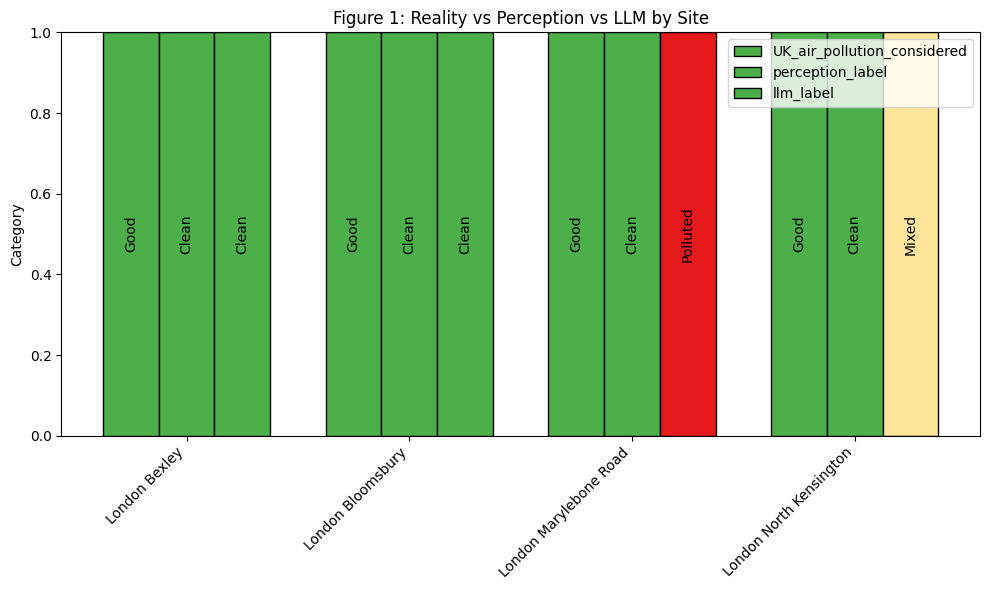

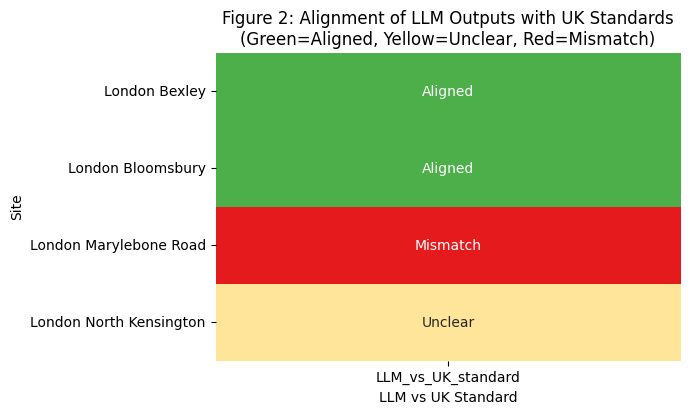

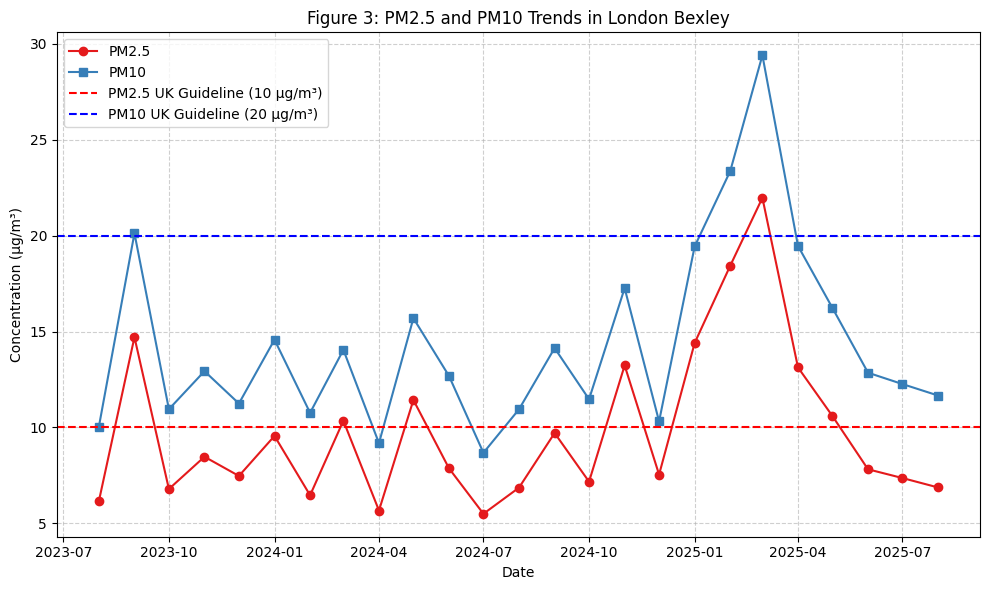

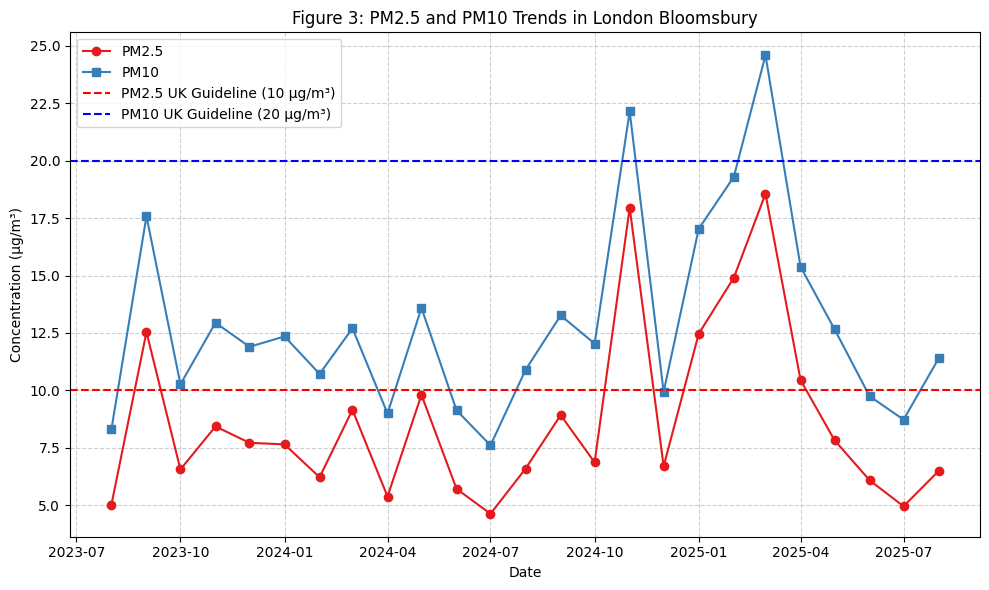

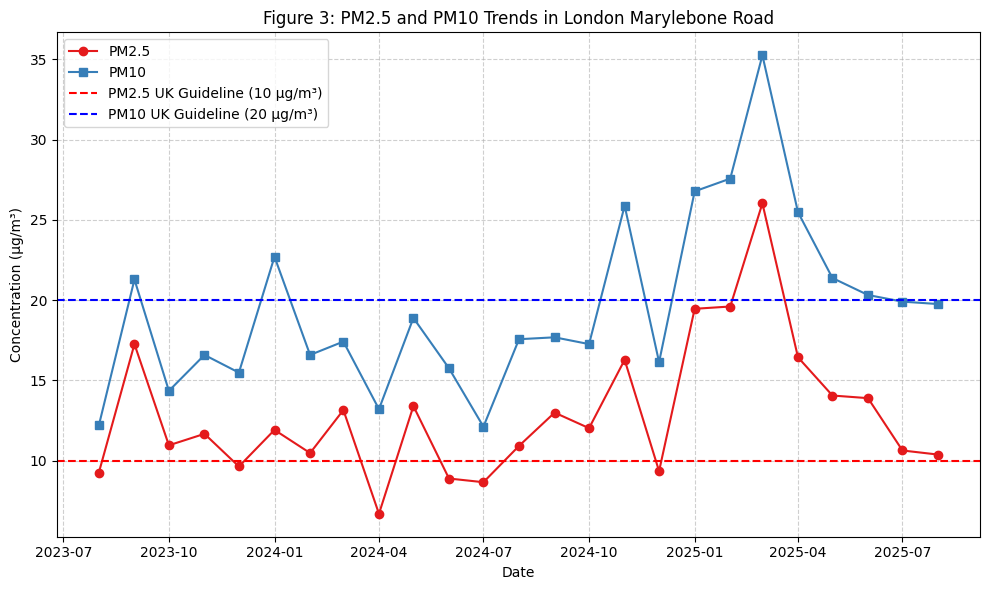

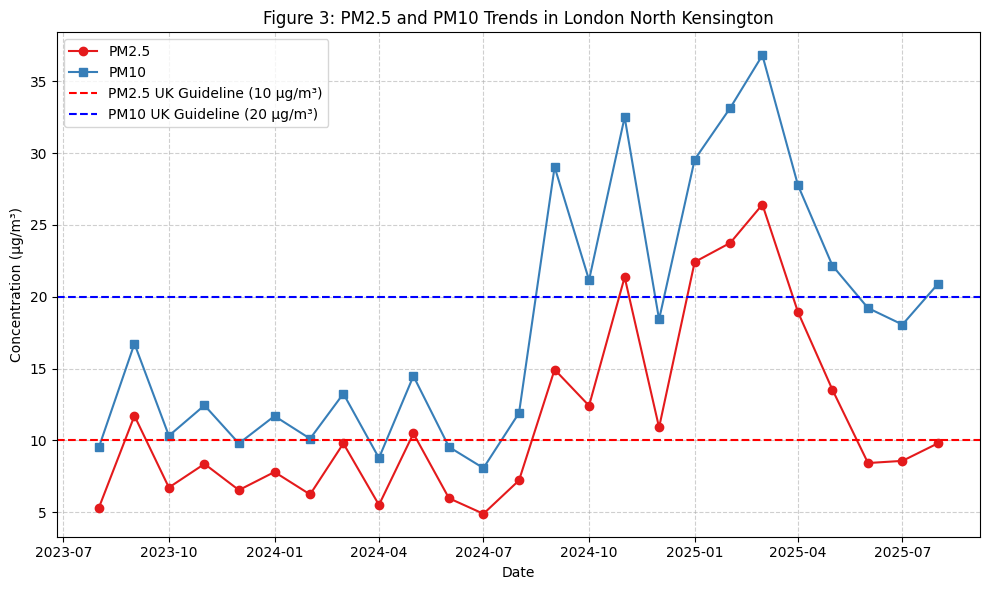

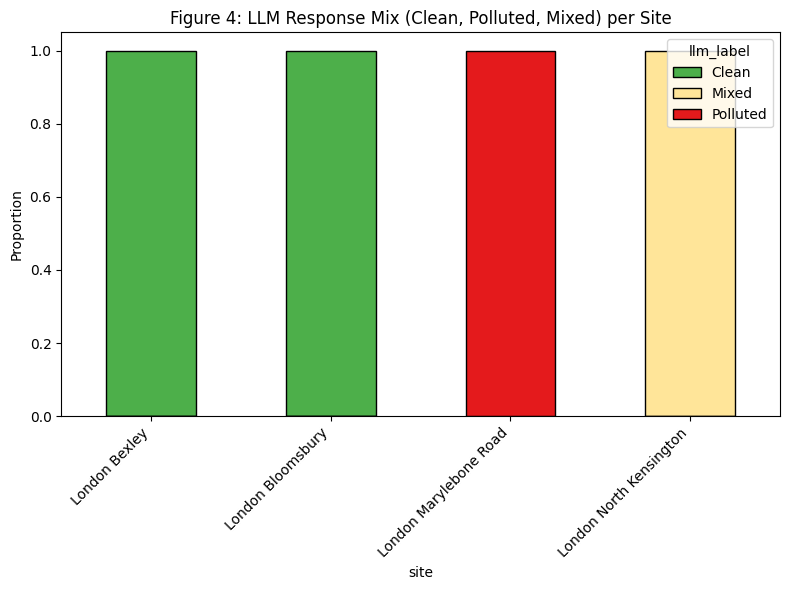

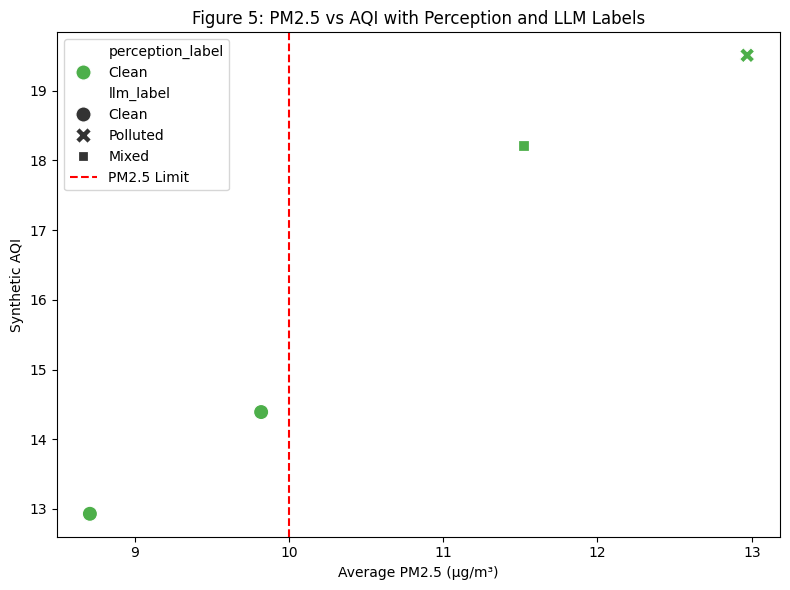

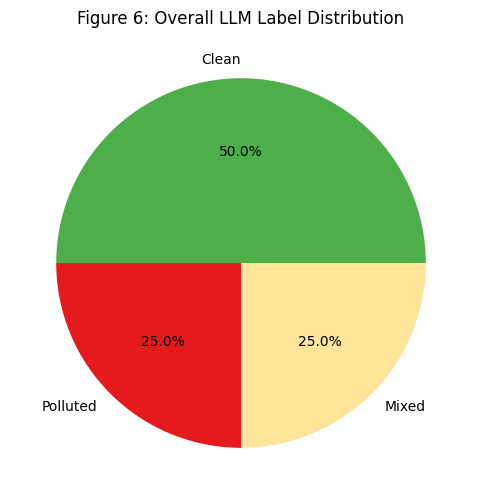

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors


condensed_path = "/content/drive/MyDrive/final datasets/new data sets/condensed_summary.csv"
time_series_path = "/content/drive/MyDrive/final datasets/new data sets/ground_truth_monthly_with_aqi.csv"

condensed_df = pd.read_csv(condensed_path)
pollution_df = pd.read_csv(time_series_path)

ng ---
category_colors = {
    "Good": "#4daf4a",
    "Clean": "#4daf4a",
    "Moderate": "#377eb8",
    "Polluted": "#e41a1c",
    "Mixed": "#ffe599",
    "Unclear": "#ffe599"
}

# Grouped Bar Chart - Reality vs Perception vs LLM

sources = ["UK_air_pollution_considered", "perception_label", "llm_label"]
width = 0.25
x = range(len(condensed_df))

fig, ax = plt.subplots(figsize=(10,6))
for idx, source in enumerate(sources):
    values = condensed_df[source]
    colors = [category_colors.get(val, "grey") for val in values]
    ax.bar([p + idx*width for p in x],
           [1]*len(condensed_df), width=width, color=colors, edgecolor="black", label=source)
    for i, val in enumerate(values):
        ax.text(i + idx*width, 0.5, val, ha='center', va='center', rotation=90, color="black")

ax.set_xticks([p + width for p in x])
ax.set_xticklabels(condensed_df["site"], rotation=45, ha="right")
ax.set_ylim(0,1)
ax.set_ylabel("Category")
ax.set_title("Figure 1: Reality vs Perception vs LLM by Site")
ax.legend()
plt.tight_layout()
plt.show()

# Heatmap - Alignment / Mismatch / Unclear
status_map = {"Mismatch":0, "Unclear":1, "Aligned":2}
heatmap_matrix = condensed_df.set_index("site")["LLM_vs_UK_standard"].map(status_map).to_frame()

# Define custom colour map (Red, Yellow, Green)
cmap = mcolors.ListedColormap(["#e41a1c", "#ffe599", "#4daf4a"])

plt.figure(figsize=(6,4))
sns.heatmap(
    heatmap_matrix,
    cmap=cmap,
    annot=condensed_df["LLM_vs_UK_standard"].values.reshape(-1,1),
    fmt="",
    cbar=False
)
plt.title("Figure 2: Alignment of LLM Outputs with UK Standards\n(Green=Aligned, Yellow=Unclear, Red=Mismatch)")
plt.ylabel("Site")
plt.xlabel("LLM vs UK Standard")
plt.show()

# Line Charts - PM2.5 & PM10 over time
pollution_df = pollution_df.rename(columns={
    "neighbourhood": "site",
    "PM2.5 particulate matter (Hourly measured)": "pm2.5",
    "PM10 particulate matter (Hourly measured)": "pm10"
})
pollution_df["Date"] = pd.to_datetime(pollution_df["Year"].astype(str) + "-" + pollution_df["Month"].astype(str) + "-01")

sites = pollution_df["site"].unique()
for site in sites:
    site_data = pollution_df[pollution_df["site"] == site]
    plt.figure(figsize=(10,6))
    plt.plot(site_data["Date"], site_data["pm2.5"], marker="o", color="#e41a1c", label="PM2.5")
    plt.plot(site_data["Date"], site_data["pm10"], marker="s", color="#377eb8", label="PM10")
    plt.axhline(10, color="red", linestyle="--", label="PM2.5 UK Guideline (10 µg/m³)")
    plt.axhline(20, color="blue", linestyle="--", label="PM10 UK Guideline (20 µg/m³)")
    plt.title(f"Figure 3: PM2.5 and PM10 Trends in {site}")
    plt.xlabel("Date")
    plt.ylabel("Concentration (µg/m³)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# Stacked Bar Chart - LLM response mix
llm_counts = condensed_df.groupby("site")["llm_label"].value_counts(normalize=True).unstack().fillna(0)

colors = [category_colors.get(col, "grey") for col in llm_counts.columns]
llm_counts.plot(kind="bar", stacked=True, figsize=(8,6), color=colors, edgecolor="black")
plt.title("Figure 4: LLM Response Mix (Clean, Polluted, Mixed) per Site")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Scatter Plot - PM2.5 vs AQI with Perception + LLM

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=condensed_df, x="pm2.5", y="aqi",
    hue="perception_label", style="llm_label", s=120,
    palette=category_colors
)
plt.axvline(10, color="red", linestyle="--", label="PM2.5 Limit")
plt.title("Figure 5: PM2.5 vs AQI with Perception and LLM Labels")
plt.xlabel("Average PM2.5 (µg/m³)")
plt.ylabel("Synthetic AQI")
plt.legend()
plt.tight_layout()
plt.show()


# Pie Chart - Overall LLM Output Distribution
plt.figure(figsize=(6,6))
condensed_df["llm_label"].value_counts().plot(
    kind="pie", autopct='%1.1f%%',
    colors=[category_colors.get(lbl, "grey") for lbl in condensed_df["llm_label"].value_counts().index]
)
plt.title("Figure 6: Overall LLM Label Distribution")
plt.ylabel("")
plt.show()


codes for visual 2

,location,aqi,pm2.5,pm10,perception_label,llm_label,UK_air_pollution_considered,LLM_vs_UK_standard
0,London Bexley,14.390000,9.820000,14.390000,Clean,Clean,Good,Aligned
1,London Bloomsbury,12.930000,8.710000,12.930000,Clean,Clean,Good,Aligned
2,London Marylebone Road,19.510000,12.970000,19.510000,Clean,Polluted,Good,Mismatch
3,London North Kensington,18.220000,11.520000,18.220000,Clean,Mixed,Good,Unclear


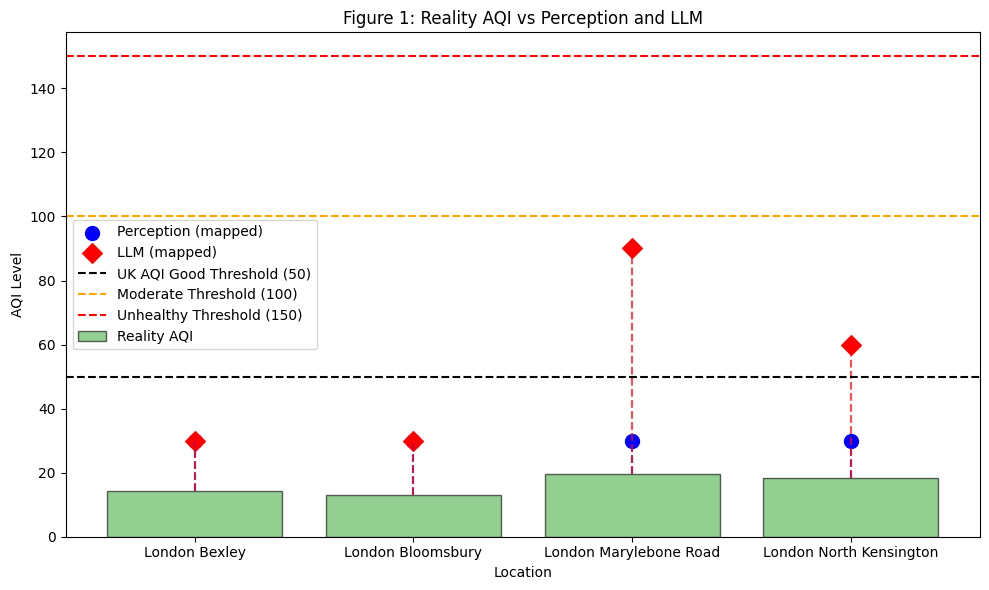

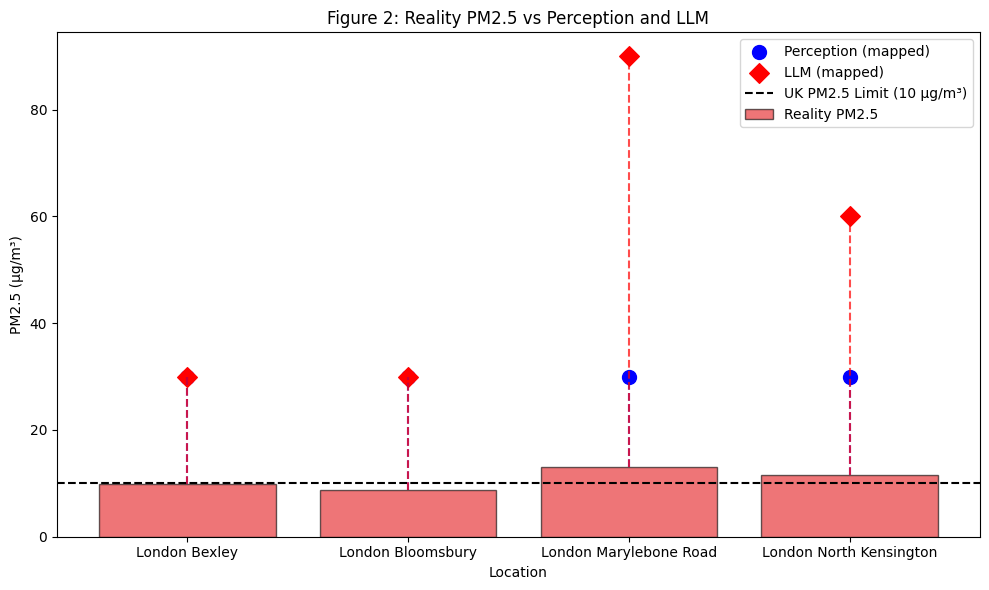

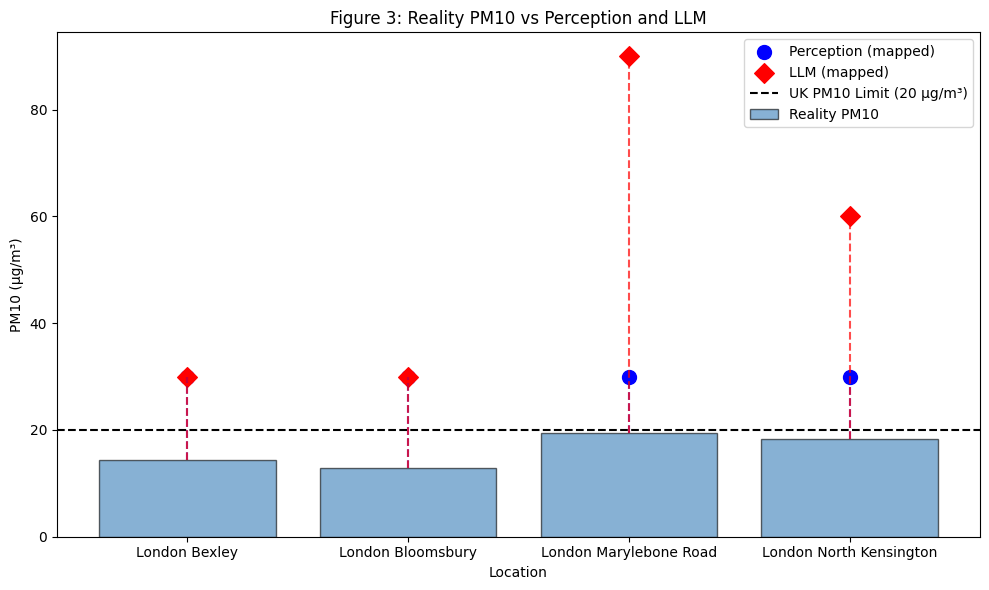

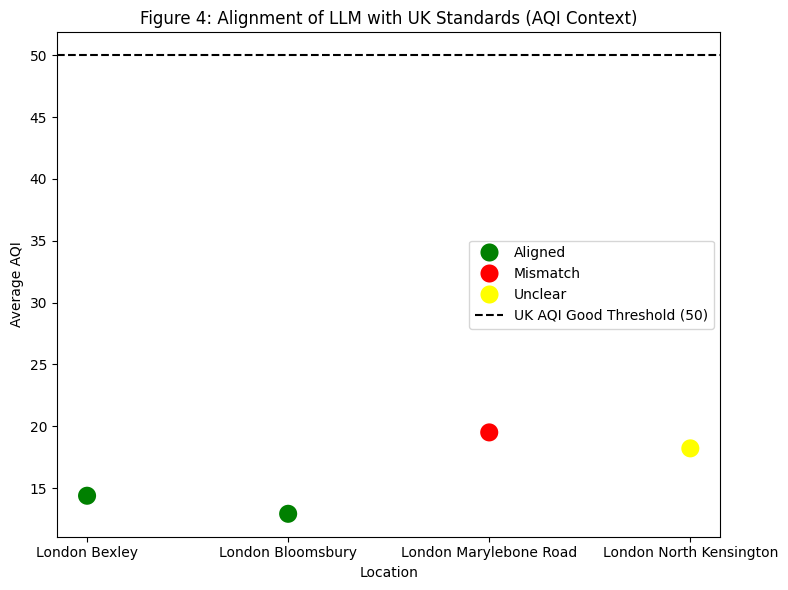

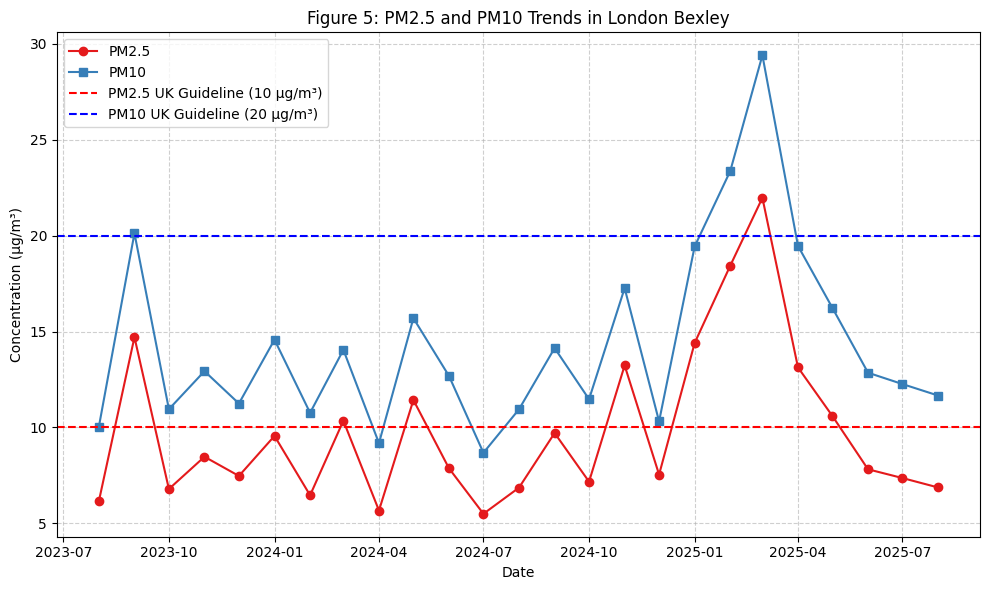

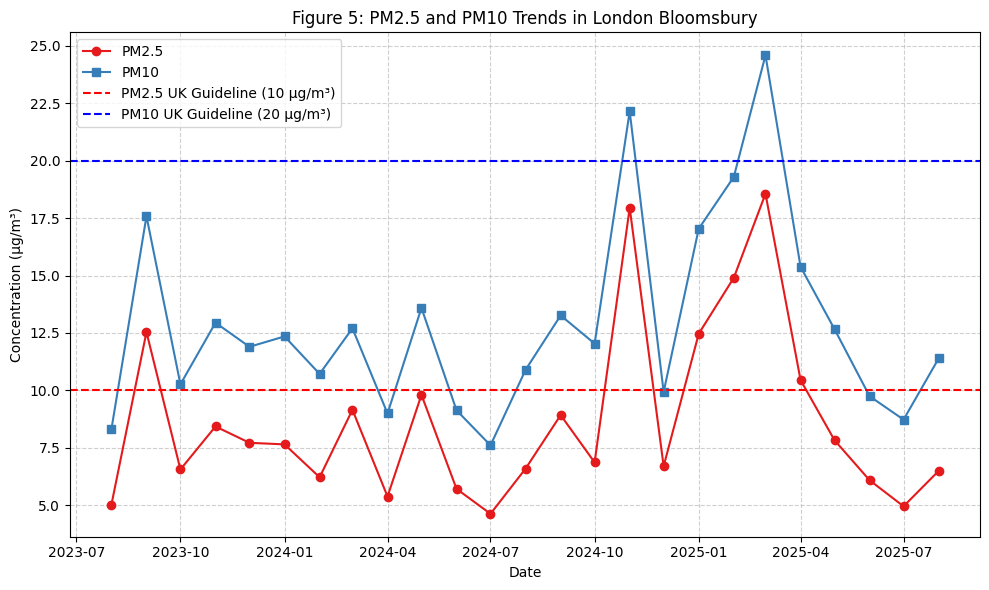

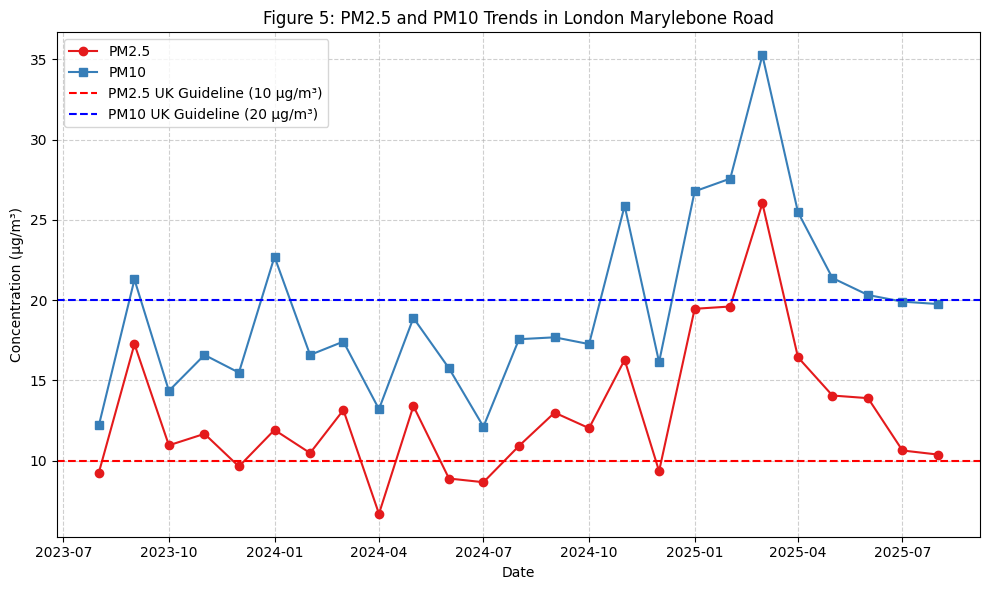

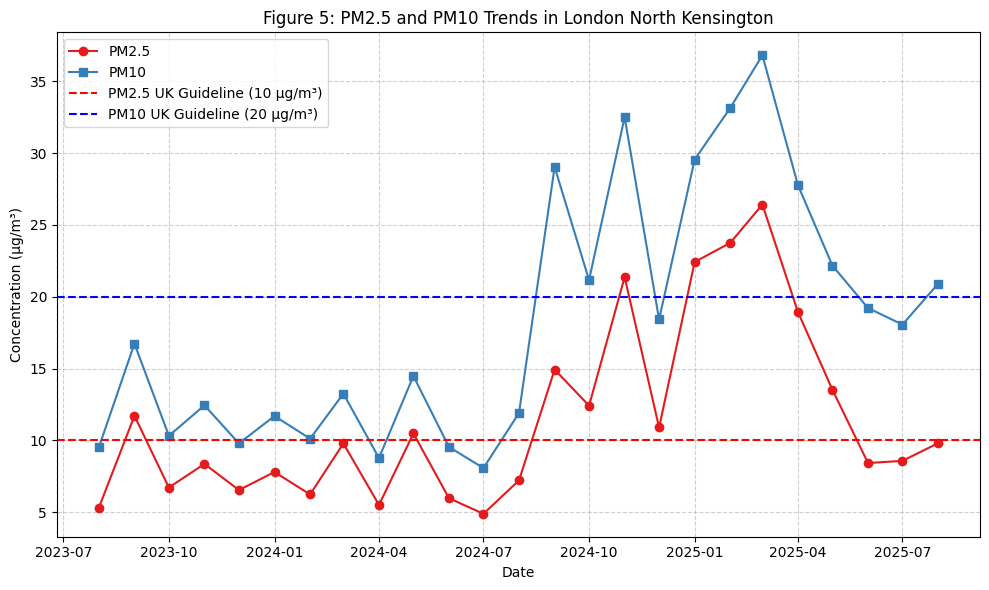

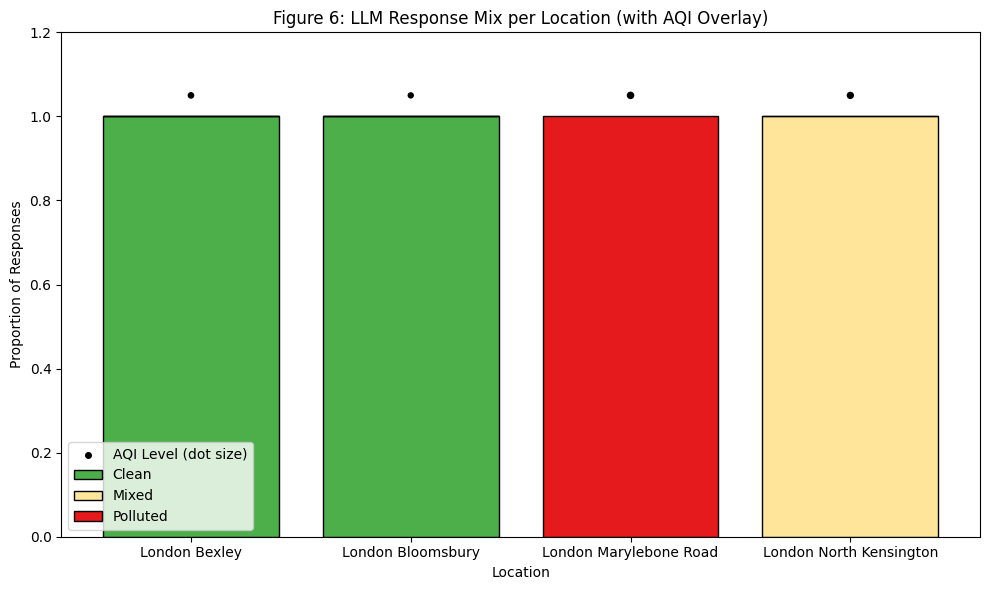

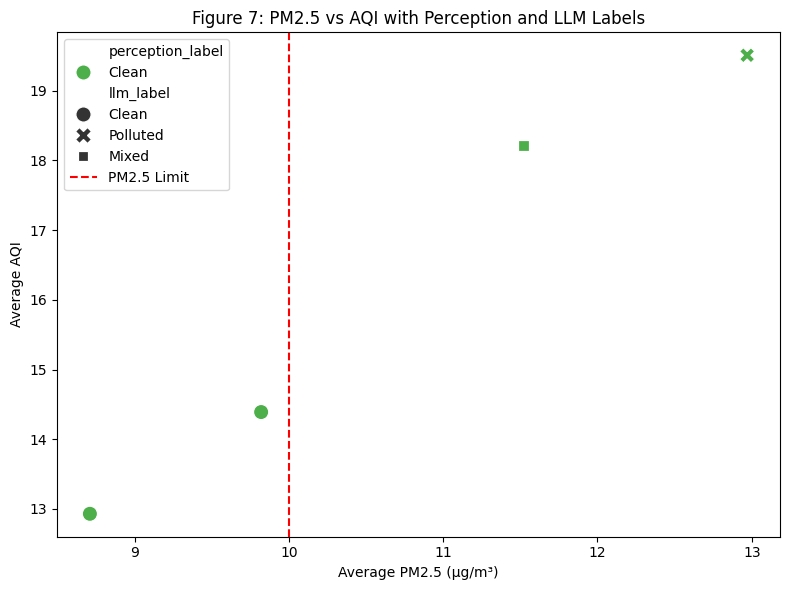

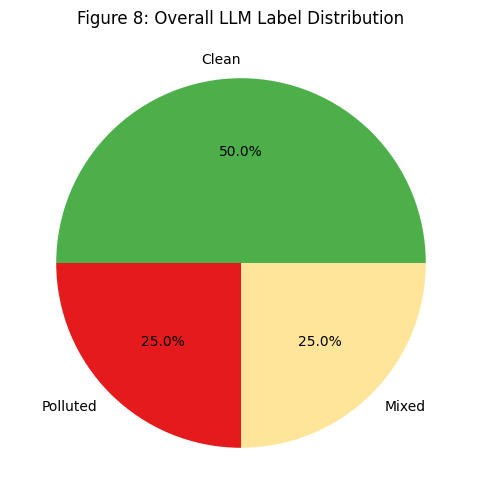

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


condensed_path = "/content/drive/MyDrive/final datasets/new data sets/condensed_summary.csv"
time_series_path = "/content/drive/MyDrive/final datasets/new data sets/ground_truth_monthly_with_aqi.csv"

df = pd.read_csv(condensed_path)
pollution_df = pd.read_csv(time_series_path)


if "site" in df.columns:
    df = df.rename(columns={"site": "location"})
if "neighbourhood" in pollution_df.columns:
    pollution_df = pollution_df.rename(columns={"neighbourhood": "location"})

category_colors = {
    "Good": "#4daf4a", "Clean": "#4daf4a",
    "Moderate": "#377eb8",
    "Polluted": "#e41a1c",
    "Mixed": "#ffe599", "Unclear": "#ffe599",
    "Aligned": "#4daf4a", "Mismatch": "#e41a1c"
}

label_to_value = {"Good": 30, "Clean": 30, "Moderate": 60, "Mixed": 60, "Polluted": 90, "Unclear": 70}

df["perception_aqi"] = df["perception_label"].map(label_to_value)
df["llm_aqi"] = df["llm_label"].map(label_to_value)
df["perception_pm25"] = df["perception_label"].map(label_to_value)
df["llm_pm25"] = df["llm_label"].map(label_to_value)
df["perception_pm10"] = df["perception_label"].map(label_to_value)
df["llm_pm10"] = df["llm_label"].map(label_to_value)

# Condensed Summary

table_data = df[[
    "location", "aqi", "pm2.5", "pm10",
    "perception_label", "llm_label",
    "UK_air_pollution_considered", "LLM_vs_UK_standard"
]]
display(table_data.style.set_caption("Table 1: Condensed Summary (Reality vs Perception vs LLM by Location)"))


# AQI (Reality vs Perception vs LLM)
plt.figure(figsize=(10,6))
bars = plt.bar(df["location"], df["aqi"], color="#4daf4a", alpha=0.6, edgecolor="black", label="Reality AQI")

plt.scatter(df["location"], df["perception_aqi"], color="blue", marker="o", s=100, label="Perception (mapped)")
plt.scatter(df["location"], df["llm_aqi"], color="red", marker="D", s=100, label="LLM (mapped)")

for i, row in df.iterrows():
    plt.plot([i, i], [row["aqi"], row["perception_aqi"]], color="blue", linestyle="--", alpha=0.7)
    plt.plot([i, i], [row["aqi"], row["llm_aqi"]], color="red", linestyle="--", alpha=0.7)

plt.axhline(50, color="black", linestyle="--", label="UK AQI Good Threshold (50)")
plt.axhline(100, color="orange", linestyle="--", label="Moderate Threshold (100)")
plt.axhline(150, color="red", linestyle="--", label="Unhealthy Threshold (150)")
plt.title("Figure 1: Reality AQI vs Perception and LLM")
plt.ylabel("AQI Level")
plt.xlabel("Location")
plt.legend()
plt.tight_layout()
plt.show()

# PM2.5 (Reality vs Perception vs LLM)

plt.figure(figsize=(10,6))
bars = plt.bar(df["location"], df["pm2.5"], color="#e41a1c", alpha=0.6, edgecolor="black", label="Reality PM2.5")

plt.scatter(df["location"], df["perception_pm25"], color="blue", marker="o", s=100, label="Perception (mapped)")
plt.scatter(df["location"], df["llm_pm25"], color="red", marker="D", s=100, label="LLM (mapped)")

for i, row in df.iterrows():
    plt.plot([i, i], [row["pm2.5"], row["perception_pm25"]], color="blue", linestyle="--", alpha=0.7)
    plt.plot([i, i], [row["pm2.5"], row["llm_pm25"]], color="red", linestyle="--", alpha=0.7)

plt.axhline(10, color="black", linestyle="--", label="UK PM2.5 Limit (10 µg/m³)")
plt.title("Figure 2: Reality PM2.5 vs Perception and LLM")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Location")
plt.legend()
plt.tight_layout()
plt.show()

# PM10 (Reality vs Perception vs LLM)

plt.figure(figsize=(10,6))
bars = plt.bar(df["location"], df["pm10"], color="#377eb8", alpha=0.6, edgecolor="black", label="Reality PM10")

plt.scatter(df["location"], df["perception_pm10"], color="blue", marker="o", s=100, label="Perception (mapped)")
plt.scatter(df["location"], df["llm_pm10"], color="red", marker="D", s=100, label="LLM (mapped)")

for i, row in df.iterrows():
    plt.plot([i, i], [row["pm10"], row["perception_pm10"]], color="blue", linestyle="--", alpha=0.7)
    plt.plot([i, i], [row["pm10"], row["llm_pm10"]], color="red", linestyle="--", alpha=0.7)

plt.axhline(20, color="black", linestyle="--", label="UK PM10 Limit (20 µg/m³)")
plt.title("Figure 3: Reality PM10 vs Perception and LLM")
plt.ylabel("PM10 (µg/m³)")
plt.xlabel("Location")
plt.legend()
plt.tight_layout()
plt.show()

# Alignment Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="location", y="aqi",
    hue="LLM_vs_UK_standard", s=200,
    palette={"Aligned":"green", "Mismatch":"red", "Unclear":"yellow"}
)
plt.axhline(50, color="black", linestyle="--", label="UK AQI Good Threshold (50)")
plt.title("Figure 4: Alignment of LLM with UK Standards (AQI Context)")
plt.ylabel("Average AQI")
plt.xlabel("Location")
plt.legend()
plt.tight_layout()
plt.show()

# PM2.5 & PM10 Time-Series Trends
pollution_df = pollution_df.rename(columns={
    "PM2.5 particulate matter (Hourly measured)": "pm2.5",
    "PM10 particulate matter (Hourly measured)": "pm10"
})
pollution_df["Date"] = pd.to_datetime(pollution_df["Year"].astype(str) + "-" + pollution_df["Month"].astype(str) + "-01")

locations = pollution_df["location"].unique()
for loc in locations:
    site_data = pollution_df[pollution_df["location"] == loc]
    plt.figure(figsize=(10,6))
    plt.plot(site_data["Date"], site_data["pm2.5"], marker="o", color="#e41a1c", label="PM2.5")
    plt.plot(site_data["Date"], site_data["pm10"], marker="s", color="#377eb8", label="PM10")
    plt.axhline(10, color="red", linestyle="--", label="PM2.5 UK Guideline (10 µg/m³)")
    plt.axhline(20, color="blue", linestyle="--", label="PM10 UK Guideline (20 µg/m³)")
    plt.title(f"Figure 5: PM2.5 and PM10 Trends in {loc}")
    plt.xlabel("Date")
    plt.ylabel("Concentration (µg/m³)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

llm_counts = df.groupby("location")["llm_label"].value_counts(normalize=True).unstack().fillna(0)

fig, ax = plt.subplots(figsize=(10,6))
bottoms = [0]*len(llm_counts)
for label in llm_counts.columns:
    vals = llm_counts[label]
    ax.bar(llm_counts.index, vals, bottom=bottoms,
           color=category_colors.get(label, "grey"), edgecolor="black", label=label)
    bottoms = [b+v for b,v in zip(bottoms, vals)]

ax.scatter(df["location"], [1.05]*len(df),
           s=df["aqi"], color="black", marker="o", label="AQI Level (dot size)")

ax.set_ylim(0,1.2)
ax.set_title("Figure 6: LLM Response Mix per Location (with AQI Overlay)")
ax.set_ylabel("Proportion of Responses")
ax.set_xlabel("Location")
ax.legend()
plt.tight_layout()
plt.show()

# PM2.5 vs AQI Scatter

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, x="pm2.5", y="aqi",
    hue="perception_label", style="llm_label", s=120,
    palette=category_colors
)
plt.axvline(10, color="red", linestyle="--", label="PM2.5 Limit")
plt.title("Figure 7: PM2.5 vs AQI with Perception and LLM Labels")
plt.xlabel("Average PM2.5 (µg/m³)")
plt.ylabel("Average AQI")
plt.legend()
plt.tight_layout()
plt.show()

# Pie Chart (LLM Label Distribution)
plt.figure(figsize=(6,6))
df["llm_label"].value_counts().plot(
    kind="pie", autopct='%1.1f%%',
    colors=[category_colors.get(lbl, "grey") for lbl in df["llm_label"].value_counts().index]
)
plt.title("Figure 8: Overall LLM Label Distribution")
plt.ylabel("")
plt.show()


Setup, Load & Preprocess + Sentiment/Emotion Analysis

In [ ]:
!pip install nltk vaderSentiment wordcloud scikit-learn --quiet

import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Load
reviews_path = "/content/drive/MyDrive/final datasets/reviews.csv"
reviews_df = pd.read_csv(reviews_path)

print("Reviews:", reviews_df.shape)
print(reviews_df.head())

# Preprocess reviews
stop_words = set(stopwords.words("english"))

def preprocess(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return " ".join(tokens)

reviews_df["clean_text"] = reviews_df["comments"].apply(preprocess)

# Sentiment (VADER)
sia = SentimentIntensityAnalyzer()
reviews_df["compound"] = reviews_df["comments"].apply(lambda x: sia.polarity_scores(str(x))["compound"])
reviews_df["sentiment"] = reviews_df["compound"].apply(lambda x: "positive" if x>0.05 else ("negative" if x<-0.05 else "neutral"))

print(reviews_df[["comments","compound","sentiment"]].head())

# NRC Emotion Lexicon
!wget -q https://raw.githubusercontent.com/cjhutto/emotion_lexicon/master/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt -O nrc_lexicon.txt

nrc = {}
with open("nrc_lexicon.txt") as f:
    for line in f:
        word, emotion, value = line.strip().split("\t")
        if int(value) == 1:
            nrc.setdefault(word, []).append(emotion)

def get_emotions(text):
    tokens = text.split()
    emotions = []
    for t in tokens:
        if t in nrc:
            emotions.extend(nrc[t])
    return emotions

reviews_df["emotions"] = reviews_df["clean_text"].sample(2000, random_state=42).apply(get_emotions)
print(reviews_df[["clean_text","emotions"]].head())


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Reviews: (2019207, 6)
   listing_id      id        date  reviewer_id reviewer_name  \
0       13913   80770  2010-08-18       177109       Michael   
1       13913  367568  2011-07-11     19835707       Mathias   
2       13913  529579  2011-09-13      1110304       Kristin   
3       13913  595481  2011-10-03      1216358       Camilla   
4       13913  612947  2011-10-09       490840         Jorik   

                                            comments  
0  My girlfriend and I hadn't known Alina before ...  
1  Alina was a really good host. The flat is clea...  
2  Alina is an amazing host. She made me feel rig...  
3  Alina's place is so nice, the room is big and ...  
4  Nice location in Islington area, good for shor...  
                                            comments  compound sentiment
0  My girlfriend and I hadn't known Alina before ...    0.9827  positive
1  Alina was a really good host. The flat is clea...    0.8122  positive
2  Alina is an amazing host. She made me fee

In [ ]:
reviews_path = "/content/drive/MyDrive/final datasets/reviews.csv"
reviews_df = pd.read_csv(reviews_path)

print("Reviews shape:", reviews_df.shape)
print(reviews_df.head(3))

stop_words = set(stopwords.words("english"))

def preprocess(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return " ".join(tokens)

reviews_df["clean_text"] = reviews_df["comments"].apply(preprocess)

# Sentiment (VADER)
sia = SentimentIntensityAnalyzer()
reviews_df["compound"] = reviews_df["comments"].apply(lambda x: sia.polarity_scores(str(x))["compound"])
reviews_df["sentiment"] = reviews_df["compound"].apply(
    lambda x: "positive" if x > 0.05 else ("negative" if x < -0.05 else "neutral")
)

print("\nSample with Sentiment:")
print(reviews_df[["comments","compound","sentiment"]].head(3))

# NRC Emotion Lexicon
!wget -q https://raw.githubusercontent.com/cjhutto/emotion_lexicon/master/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt -O nrc_lexicon.txt

nrc = {}
with open("nrc_lexicon.txt") as f:
    for line in f:
        word, emotion, value = line.strip().split("\t")
        if int(value) == 1:
            nrc.setdefault(word, []).append(emotion)

def get_emotions(text):
    tokens = text.split()
    emotions = []
    for t in tokens:
        if t in nrc:
            emotions.extend(nrc[t])
    return emotions

sampled = reviews_df.sample(2000, random_state=42).copy()
sampled["emotions"] = sampled["clean_text"].apply(get_emotions)


def dominant_emotion(emotion_list):
    if not emotion_list:
        return None
    counts = Counter(emotion_list)
    return counts.most_common(1)[0][0]

sampled["dominant_emotion"] = sampled["emotions"].apply(dominant_emotion)

print("\nSample with Emotions:")
print(sampled[["clean_text","dominant_emotion"]].head(5))

Reviews shape: (2019207, 6)
   listing_id      id        date  reviewer_id reviewer_name  \
0       13913   80770  2010-08-18       177109       Michael   
1       13913  367568  2011-07-11     19835707       Mathias   
2       13913  529579  2011-09-13      1110304       Kristin   

                                            comments  
0  My girlfriend and I hadn't known Alina before ...  
1  Alina was a really good host. The flat is clea...  
2  Alina is an amazing host. She made me feel rig...  

Sample with Sentiment:
                                            comments  compound sentiment
0  My girlfriend and I hadn't known Alina before ...    0.9827  positive
1  Alina was a really good host. The flat is clea...    0.8122  positive
2  Alina is an amazing host. She made me feel rig...    0.9722  positive

Sample with Emotions:
                                                clean_text dominant_emotion
806879                                   nice house thanks             None
1748

In [ ]:
reviews_path = "/content/drive/MyDrive/final datasets/reviews.csv"
listings_path = "/content/drive/MyDrive/final datasets/listings.csv"

reviews_df = pd.read_csv(reviews_path)
listings_df = pd.read_csv(listings_path)

listings_df = listings_df[["id", "neighbourhood"]].rename(columns={"id":"listing_id"})
reviews_mapped = reviews_df.merge(listings_df, on="listing_id", how="left")

focus_locs = ["Bexley", "Bloomsbury", "Marylebone Road", "North Kensington"]
reviews_focus = reviews_mapped[reviews_mapped["neighbourhood"].isin(focus_locs)].copy()

print("Reviews shape (focus):", reviews_focus.shape)

# Sentiment
sia = SentimentIntensityAnalyzer()
reviews_focus["compound"] = reviews_focus["comments"].apply(lambda x: sia.polarity_scores(str(x))["compound"])
reviews_focus["sentiment"] = reviews_focus["compound"].apply(
    lambda x: "positive" if x > 0.05 else ("negative" if x < -0.05 else "neutral")
)

output_path = "/content/drive/MyDrive/final datasets/reviews_focus_vader.csv"
reviews_focus.to_csv(output_path, index=False)

print("VADER analysis saved to:", output_path)
print(reviews_focus[["neighbourhood","comments","compound","sentiment"]].head(10))

Reviews shape (focus): (7329, 7)
VADER analysis saved to: /content/drive/MyDrive/final datasets/reviews_focus_vader.csv
      neighbourhood                                           comments  \
65637        Bexley  I had a very comfort stay at Braiden.I felt al...   
65638        Bexley  Our stay here was good, Braiden and his family...   
65639        Bexley  Great hosts! I would be glad to stay there again.   
65640        Bexley  Just as we arrived we get lost, but David told...   
65641        Bexley    I had a good welcome of Braiden and his family.   
65642        Bexley  I moved in London for working so i decided to ...   
65643        Bexley  I felt very welcome by Braiden and his family ...   
65747        Bexley  If you need a bed in London and you are on a b...   
65748        Bexley  Dear Fellow AirBnBers,\r<br/>\r<br/> I lived a...   
65749        Bexley  My stay at Braiden's was good. The family was ...   

       compound sentiment  
65637    0.8643  positive  
65638    

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Sample reviews
sample_reviews = reviews_df["clean_text"].sample(2000, random_state=42)

# Vectorize text
vectorizer = CountVectorizer(max_df=0.9, min_df=20, stop_words="english")
dtm = vectorizer.fit_transform(sample_reviews)

# Fit lightweight LDA
lda = LatentDirichletAllocation(n_components=3, max_iter=5, random_state=42)
lda.fit(dtm)

words = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    print(f"Topic {i}: ", [words[j] for j in topic.argsort()[-10:]])


Topic 0:  ['really', 'london', 'location', 'recommend', 'apartment', 'clean', 'host', 'great', 'place', 'stay']
Topic 1:  ['flat', 'nice', 'clean', 'good', 'place', 'london', 'stay', 'room', 'location', 'great']
Topic 2:  ['es', 'muy', 'bien', 'und', 'en', 'le', 'est', 'très', 'et', 'la']


Refined dataset created:                   location      pm2.5       pm10        aqi  \
0            London Bexley   9.822906  14.388019  14.388019   
1        London Bloomsbury   8.706826  12.927577  12.927577   
2   London Marylebone Road  12.968123  19.506066  19.506066   
3  London North Kensington  11.523864  18.216843  18.216843   

  UK_air_pollution_considered llm_label  \
0                        Good     Clean   
1                        Good     Clean   
2                        Good  Polluted   
3                        Good     Mixed   

                                            response  
0  The air quality in Bexley is generally clean a...  
1  The air quality in Bloomsbury is generally mod...  
2  The air quality along Marylebone Road is often...  
3  The air quality in North Kensington is general...  
Confusion Matrix:
 [[2 1 1]
 [0 0 0]
 [0 0 0]]
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         4
           1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


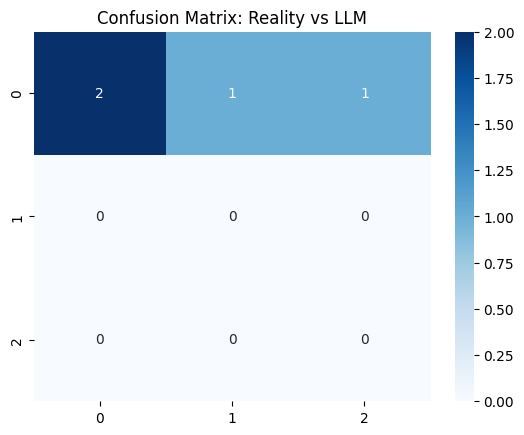

Chi-Square Wealth Bias Test: chi2= 0.0 p-value= 1.0

Aligned Example:
 The atmosphere is moderately clean, with some variation depending on weather and traffic. Noise adds to the urban character but is not extreme. Overall, it feels healthy enough for daily life in London.

Mismatch Example:
 Yes, North Kensington is broadly considered a polluted area within the context of London due to its inner-city location and high traffic volume. Its environment consistently records moderate to poor air quality, characteristic of areas inside the city's main circular roads. Consequently, it is not regarded as a place with a consistently healthy or clean atmosphere.

Unclear Example:
 The air quality in North Kensington is generally moderate, with some days feeling clean and others affected by traffic. Noise is present around main roads but quieter in residential zones. Overall, the environment feels mixed but manageable for city living.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from scipy.stats import chi2_contingency

# Load datasets
reality_path = "/content/drive/MyDrive/final datasets/new data sets/ground_truth_monthly_with_aqi.csv"
llm_path = "/content/drive/MyDrive/final datasets/new data sets/llm_outputs_labeled.csv"

reality_df = pd.read_csv(reality_path)
llm_df = pd.read_csv(llm_path)

# Reality summary
reality_df = reality_df.rename(columns={
    "neighbourhood":"location",
    "PM2.5 particulate matter (Hourly measured)":"pm2.5",
    "PM10 particulate matter (Hourly measured)":"pm10"
})
reality_summary = reality_df.groupby("location").agg({"pm2.5":"mean","pm10":"mean"}).reset_index()
reality_summary["aqi"] = reality_summary[["pm2.5","pm10"]].max(axis=1)

def pollution_category(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Moderate"
    else: return "Polluted"

reality_summary["UK_air_pollution_considered"] = reality_summary["aqi"].apply(pollution_category)

# LLM outputs
llm_df = llm_df.rename(columns={"neighbourhood":"location", "llm_label_auto":"llm_label"})

llm_summary = llm_df.groupby("location").agg({
    "llm_label": lambda x: x.mode()[0] if not x.mode().empty else None,
    "response": lambda x: x.iloc[0]
}).reset_index()

# Merge into refined dataset
refined_df = reality_summary.merge(llm_summary, on="location", how="left")
refined_df.to_csv("/content/drive/MyDrive/final datasets/new data sets/refined_dataset.csv", index=False)

print("Refined dataset created:", refined_df.head())


# Quantitative evaluation
label_map = {"Good":0,"Clean":0,"Moderate":1,"Mixed":1,"Polluted":2,"Unclear":1}
refined_df["reality_class"] = refined_df["UK_air_pollution_considered"].map(label_map)
refined_df["llm_class"] = refined_df["llm_label"].map(label_map)

cm = confusion_matrix(refined_df["reality_class"], refined_df["llm_class"])
print("Confusion Matrix:\n", cm)
print(classification_report(refined_df["reality_class"], refined_df["llm_class"]))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Reality vs LLM")
plt.show()


# Bias test
wealthy = ["Kensington"]
refined_df["wealth_status"] = refined_df["location"].apply(lambda x: "wealthy" if x in wealthy else "non_wealthy")
contingency = pd.crosstab(refined_df["wealth_status"], refined_df["llm_label"])
chi2, p, dof, ex = chi2_contingency(contingency)
print("Chi-Square Wealth Bias Test: chi2=", chi2, "p-value=", p)


# Qualitative examples
aligned_example = llm_df[llm_df["llm_label"]=="Clean"].iloc[0]["response"]
mismatch_example = llm_df[llm_df["llm_label"]=="Polluted"].iloc[0]["response"]
unclear_example = llm_df[llm_df["llm_label"]=="Mixed"].iloc[0]["response"]

print("\nAligned Example:\n", aligned_example)
print("\nMismatch Example:\n", mismatch_example)
print("\nUnclear Example:\n", unclear_example)


In [ ]:
import pandas as pd

reviews_path = "/content/drive/MyDrive/final datasets/reviews.csv"
reviews_df = pd.read_csv(reviews_path)

print(reviews_df.columns.tolist())
print(reviews_df.head())

['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments']
   listing_id      id        date  reviewer_id reviewer_name  \
0       13913   80770  2010-08-18       177109       Michael   
1       13913  367568  2011-07-11     19835707       Mathias   
2       13913  529579  2011-09-13      1110304       Kristin   
3       13913  595481  2011-10-03      1216358       Camilla   
4       13913  612947  2011-10-09       490840         Jorik   

                                            comments  
0  My girlfriend and I hadn't known Alina before ...  
1  Alina was a really good host. The flat is clea...  
2  Alina is an amazing host. She made me feel rig...  
3  Alina's place is so nice, the room is big and ...  
4  Nice location in Islington area, good for shor...  


In [ ]:
import pandas as pd

# Load Reality (Air Quality)

reality_path = "/content/drive/MyDrive/final datasets/new data sets/ground_truth_monthly_with_aqi.csv"
reality_df = pd.read_csv(reality_path)


reality_df = reality_df.rename(columns={
    "Year": "year",
    "Month": "month",
    "PM2.5 particulate matter (Hourly measured)": "pm2.5",
    "PM10 particulate matter (Hourly measured)": "pm10"
})

reality_df["year"] = reality_df["year"].astype(int)
reality_df["month"] = reality_df["month"].astype(int)


reality_df["neighbourhood"] = reality_df["neighbourhood"].str.replace("London ", "", regex=False).str.strip()

# Group monthly averages
reality_monthly = reality_df.groupby(["neighbourhood","year","month"]).agg({
    "pm2.5":"mean",
    "pm10":"mean"
}).reset_index()

# Majority
def majority_vote(series):
    return series.mode()[0] if not series.mode().empty else None

aqi_monthly = reality_df.groupby(["neighbourhood","year","month"]).agg({
    "AQI_PM25_category": majority_vote,
    "AQI_PM10_category": majority_vote
}).reset_index()

reality_monthly = reality_monthly.merge(aqi_monthly, on=["neighbourhood","year","month"], how="left")

print("\n Reality Monthly (first 10 rows):")
print(reality_monthly.head(10))

# Load Reviews (VADER Sentiment)

reviews_path = "/content/drive/MyDrive/final datasets/reviews_focus_vader.csv"
reviews_df = pd.read_csv(reviews_path)

# Convert dates
reviews_df["date"] = pd.to_datetime(reviews_df["date"])
reviews_df["year"] = reviews_df["date"].dt.year.astype(int)
reviews_df["month"] = reviews_df["date"].dt.month.astype(int)

# Clean neighbourhoods
reviews_df["neighbourhood"] = reviews_df["neighbourhood"].str.strip()

# Aggregate monthly sentiment
perception_monthly = reviews_df.groupby(["neighbourhood","year","month"]).agg({
    "compound": "mean",
    "sentiment": majority_vote,
    "listing_id": "count"
}).reset_index().rename(columns={"compound":"avg_compound","listing_id":"review_count"})

print("\n Perception Monthly (first 10 rows):")
print(perception_monthly.head(10))

#  Merge Reality + Perception

merged_monthly = reality_monthly.merge(perception_monthly, on=["neighbourhood","year","month"], how="outer")

print("\n Merged Monthly (first 15 rows):")
print(merged_monthly.head(15))

# Save
output_path = "/content/drive/MyDrive/final datasets/new data sets/monthly_perception_reality.csv"
merged_monthly.to_csv(output_path, index=False)
print("\n File saved to:", output_path)



🔎 Reality Monthly (first 10 rows):
  neighbourhood  year  month      pm2.5       pm10 AQI_PM25_category  \
0        Bexley  2023      8   6.156419  10.035484              Good   
1        Bexley  2023      9  14.704433  20.120000          Moderate   
2        Bexley  2023     10   6.792613  10.951613              Good   
3        Bexley  2023     11   8.474867  12.933333              Good   
4        Bexley  2023     12   7.474161  11.248387              Good   
5        Bexley  2024      1   9.558774  14.574194              Good   
6        Bexley  2024      2   6.467172  10.762069              Good   
7        Bexley  2024      3  10.353097  14.045161              Good   
8        Bexley  2024      4   5.673000   9.183333              Good   
9        Bexley  2024      5  11.430419  15.693548              Good   

  AQI_PM10_category  
0              Good  
1              Good  
2              Good  
3              Good  
4              Good  
5              Good  
6              Go

In [ ]:
import pandas as pd

# Load raw reviews dataset
reviews_path = "/content/drive/MyDrive/final datasets/reviews.csv"
reviews_df = pd.read_csv(reviews_path)

# Display first 10 rows
print(" First 10 rows of reviews.csv:")
print(reviews_df.head(10))

# Display last 10 rows
print("\n Last 10 rows of reviews.csv:")
print(reviews_df.tail(10))

# Also print date range for clarity
if "date" in reviews_df.columns:
    reviews_df["date"] = pd.to_datetime(reviews_df["date"], errors="coerce")
    print("\n Date range in dataset:")
    print("Earliest:", reviews_df["date"].min())
    print("Latest:", reviews_df["date"].max())


🔎 First 10 rows of reviews.csv:
   listing_id        id        date  reviewer_id reviewer_name  \
0       13913     80770  2010-08-18       177109       Michael   
1       13913    367568  2011-07-11     19835707       Mathias   
2       13913    529579  2011-09-13      1110304       Kristin   
3       13913    595481  2011-10-03      1216358       Camilla   
4       13913    612947  2011-10-09       490840         Jorik   
5       13913   4847959  2013-05-28      6405442          Vera   
6       13913   8142329  2013-10-17      9195551          Honi   
7       13913  11876590  2014-04-17      5194009    Alessandro   
8       13913  46669566  2015-09-12     42970248          Oleh   
9       13913  64559033  2016-03-05     45337884            Mo   

                                            comments  
0  My girlfriend and I hadn't known Alina before ...  
1  Alina was a really good host. The flat is clea...  
2  Alina is an amazing host. She made me feel rig...  
3  Alina's place is s

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import confusion_matrix, classification_report
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns


!pip install afinn --quiet
from afinn import Afinn

nltk.download("vader_lexicon")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Perception sample:
                                            comments  compound sentiment  \
0  I had a very comfort stay at Braiden.I felt al...    0.8643  positive   
1  Our stay here was good, Braiden and his family...    0.9185  positive   
2  Great hosts! I would be glad to stay there again.    0.8122  positive   
3  Just as we arrived we get lost, but David told...    0.9522  positive   
4    I had a good welcome of Braiden and his family.    0.7096  positive   

   afinn_score dominant_emotion  
0          8.0             None  
1         12.0             None  
2          6.0             None  
3          5.0             None  
4          5.0             None  

Topic 0: ['clean', 'london', 'station', 'nice', 'lovely', 'good', 'host', 'stay', 'great', 'place']

Topic 1: ['great', 'nice', 'comfortable', 'place', 'house', 'room', 'recommend', 'clean', 'host', 'stay']

Topic 2: ['es', 'logement', 'que', 'le', 'est', 'muy', 'très', 'et', 'en', 'la']

Reality summary:
      neighb

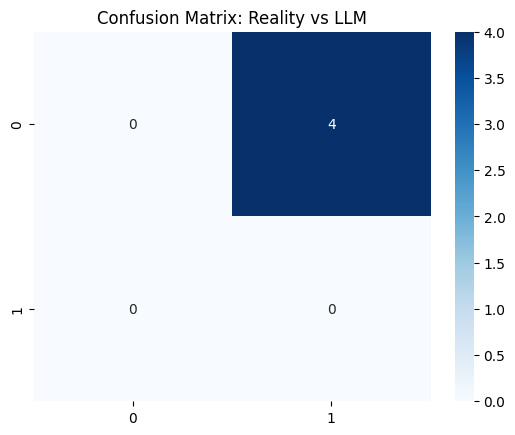


Chi-Square Wealth Bias Test skipped: only one LLM label present

Aligned Example:
 The atmosphere is moderately clean, with some variation depending on weather and traffic. Noise adds to the urban character but is not extreme. Overall, it feels healthy enough for daily life in London.

Mismatch Example:
 Yes, North Kensington is broadly considered a polluted area within the context of London due to its inner-city location and high traffic volume. Its environment consistently records moderate to poor air quality, characteristic of areas inside the city's main circular roads. Consequently, it is not regarded as a place with a consistently healthy or clean atmosphere.

Unclear Example:
 The air quality in North Kensington is generally moderate, with some days feeling clean and others affected by traffic. Noise is present around main roads but quieter in residential zones. Overall, the environment feels mixed but manageable for city living.


In [ ]:

reviews_path = "/content/drive/MyDrive/final datasets/reviews_focus_vader.csv"
reality_path = "/content/drive/MyDrive/final datasets/new data sets/ground_truth_monthly_with_aqi.csv"
llm_path = "/content/drive/MyDrive/final datasets/new data sets/llm_outputs_labeled.csv"


reviews_df = pd.read_csv(reviews_path)

# Preprocess text
def preprocess(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return " ".join(tokens)

reviews_df["clean_text"] = reviews_df["comments"].apply(preprocess)

# VADER
sia = SentimentIntensityAnalyzer()
reviews_df["compound"] = reviews_df["comments"].apply(lambda x: sia.polarity_scores(str(x))["compound"])
reviews_df["sentiment"] = reviews_df["compound"].apply(
    lambda x: "positive" if x > 0.05 else ("negative" if x < -0.05 else "neutral")
)

# Afinn
af = Afinn()
reviews_df["afinn_score"] = reviews_df["comments"].apply(lambda x: af.score(str(x)))

# NRC Emotion Lexicon
!wget -q https://raw.githubusercontent.com/cjhutto/emotion_lexicon/master/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt -O nrc_lexicon.txt
nrc = {}
with open("nrc_lexicon.txt") as f:
    for line in f:
        word, emotion, value = line.strip().split("\t")
        if int(value) == 1:
            nrc.setdefault(word, []).append(emotion)

def get_emotions(text):
    tokens = text.split()
    emotions = []
    for t in tokens:
        if t in nrc:
            emotions.extend(nrc[t])
    return emotions

def dominant_emotion(emotion_list):
    if not emotion_list: return None
    counts = Counter(emotion_list)
    return counts.most_common(1)[0][0]

reviews_df["emotions"] = reviews_df["clean_text"].apply(get_emotions)
reviews_df["dominant_emotion"] = reviews_df["emotions"].apply(dominant_emotion)

print("Perception sample:")
print(reviews_df[["comments","compound","sentiment","afinn_score","dominant_emotion"]].head())

# Topic Modelling (LDA)

vectorizer = CountVectorizer(max_df=0.9, min_df=20, stop_words="english")
dtm = vectorizer.fit_transform(reviews_df["clean_text"].sample(3000, random_state=42))
lda = LatentDirichletAllocation(n_components=3, max_iter=5, random_state=42)
lda.fit(dtm)

words = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    print(f"\nTopic {i}: {[words[j] for j in topic.argsort()[-10:]]}")


# Reality (Air Quality)

reality_df = pd.read_csv(reality_path)
reality_df = reality_df.rename(columns={
    "Year":"year",
    "Month":"month",
    "PM2.5 particulate matter (Hourly measured)":"pm2.5",
    "PM10 particulate matter (Hourly measured)":"pm10"
})
reality_df["neighbourhood"] = reality_df["neighbourhood"].str.replace("London ","",regex=False)

reality_summary = reality_df.groupby("neighbourhood").agg({"pm2.5":"mean","pm10":"mean"}).reset_index()
reality_summary["aqi"] = reality_summary[["pm2.5","pm10"]].max(axis=1)

def pollution_category(aqi):
    if aqi <= 50: return "Good"
    elif aqi <= 100: return "Moderate"
    else: return "Polluted"
reality_summary["aqi_category"] = reality_summary["aqi"].apply(pollution_category)

print("\nReality summary:")
print(reality_summary.head())


# LLM Outputs (Evaluation)

llm_df = pd.read_csv(llm_path)
llm_df = llm_df.rename(columns={"neighbourhood":"location","llm_label_auto":"llm_label"})

llm_summary = llm_df.groupby("location").agg({
    "llm_label": lambda x: x.mode()[0],
    "response": lambda x: x.iloc[0]
}).reset_index()

# Merge with reality
merged_eval = reality_summary.merge(llm_summary, left_on="neighbourhood", right_on="location", how="left")

# Expanded label map
label_map = {
    "Good": 0, "Clean": 0, "Healthy": 0, "Safe": 0,
    "Moderate": 1, "Mixed": 1, "Unclear": 1,
    "Polluted": 2, "Dirty": 2, "Hazardous": 2
}

# Map classes
merged_eval["reality_class"] = merged_eval["aqi_category"].map(label_map)
merged_eval["llm_class"] = merged_eval["llm_label"].map(label_map).fillna(1)

# Drop any NaN just in case
merged_eval = merged_eval.dropna(subset=["reality_class","llm_class"])


# Confusion Matrix Evaluation

# Map classes again for safety
label_map = {
    "Good": 0, "Clean": 0, "Healthy": 0, "Safe": 0,
    "Moderate": 1, "Mixed": 1, "Unclear": 1,
    "Polluted": 2, "Dirty": 2, "Hazardous": 2
}

merged_eval["reality_class"] = merged_eval["aqi_category"].map(label_map)
merged_eval["llm_class"] = merged_eval["llm_label"].map(label_map).fillna(1)

# Drop NaN rows
merged_eval = merged_eval.dropna(subset=["reality_class","llm_class"])

# Confusion matrix
cm = confusion_matrix(merged_eval["reality_class"], merged_eval["llm_class"])
print("\nConfusion Matrix:\n", cm)
print(classification_report(
    merged_eval["reality_class"],
    merged_eval["llm_class"],
    zero_division=0
))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Reality vs LLM")
plt.show()

# Bias Test (Wealth vs Non-Wealthy)
wealthy = ["Kensington"]
merged_eval["wealth_status"] = merged_eval["neighbourhood"].apply(
    lambda x: "wealthy" if x in wealthy else "non_wealthy"
)

contingency = pd.crosstab(merged_eval["wealth_status"], merged_eval["llm_label"])

if contingency.shape[1] > 1:
    chi2, p, dof, ex = chi2_contingency(contingency)
    print("\nChi-Square Wealth Bias Test: chi2=", chi2, "p-value=", p)
else:
    print("\nChi-Square Wealth Bias Test skipped: only one LLM label present")

# Qualitative Examples
try:
    aligned_example = llm_df[llm_df["llm_label"]=="Clean"].iloc[0]["response"]
except:
    aligned_example = "No Clean label found."

try:
    mismatch_example = llm_df[llm_df["llm_label"]=="Polluted"].iloc[0]["response"]
except:
    mismatch_example = "No Polluted label found."

try:
    unclear_example = llm_df[llm_df["llm_label"]=="Mixed"].iloc[0]["response"]
except:
    unclear_example = "No Mixed label found."

print("\nAligned Example:\n", aligned_example)
print("\nMismatch Example:\n", mismatch_example)
print("\nUnclear Example:\n", unclear_example)


In [ ]:
import pandas as pd

reviews = pd.read_csv("/content/drive/MyDrive/final datasets/reviews_focus_vader.csv")

# Standardising
name_map = {
    "Bexley": "London Bexley",
    "Bloomsbury": "London Bloomsbury",
    "Marylebone Road": "London Marylebone Road",
    "North Kensington": "London North Kensington"
}
if "neighbourhood" in reviews.columns:
    reviews["neighbourhood"] = reviews["neighbourhood"].replace(name_map)


reviews["date"] = pd.to_datetime(reviews["date"], errors="coerce")
reviews["Year"] = reviews["date"].dt.year
reviews["Month"] = reviews["date"].dt.month

#  monthly Aggregate perception
def majority_vote(series):
    return series.mode()[0] if not series.mode().empty else None

perception_monthly = (
    reviews.groupby(["neighbourhood","Year","Month"])
    .agg(
        avg_compound=("compound","mean"),
        sentiment=("sentiment", majority_vote),
        review_count=("id","count")
    )
    .reset_index()
)

all_neighbourhoods = ["London Bexley","London Bloomsbury","London Marylebone Road","London North Kensington"]
all_periods = perception_monthly[["Year","Month"]].drop_duplicates()

all_index = all_periods.assign(key=1).merge(pd.DataFrame(all_neighbourhoods, columns=["neighbourhood"]).assign(key=1), on="key").drop("key", axis=1)

perception_complete = all_index.merge(perception_monthly, on=["neighbourhood","Year","Month"], how="left")


save_path = "/content/drive/MyDrive/final datasets/new data sets/perception_summary_monthly_complete.csv"
perception_complete.to_csv(save_path, index=False)

print(f" Complete monthly perception summary saved at {save_path}")
print(perception_complete.head(20))


✅ Complete monthly perception summary saved at /content/drive/MyDrive/final datasets/new data sets/perception_summary_monthly_complete.csv
    Year  Month            neighbourhood  avg_compound sentiment  review_count
0   2013     11            London Bexley       0.86430  positive           1.0
1   2013     11        London Bloomsbury           NaN       NaN           NaN
2   2013     11   London Marylebone Road           NaN       NaN           NaN
3   2013     11  London North Kensington           NaN       NaN           NaN
4   2014      6            London Bexley       0.86535  positive           2.0
5   2014      6        London Bloomsbury           NaN       NaN           NaN
6   2014      6   London Marylebone Road           NaN       NaN           NaN
7   2014      6  London North Kensington           NaN       NaN           NaN
8   2014      7            London Bexley       0.95220  positive           1.0
9   2014      7        London Bloomsbury           NaN       NaN       

In [ ]:
import pandas as pd

# Load datasets
aqi = pd.read_csv("/content/drive/MyDrive/final datasets/new data sets/ground_truth_monthly_with_aqi.csv")
reviews = pd.read_csv("/content/drive/MyDrive/final datasets/new data sets/perception_summary_monthly_complete.csv")
llm = pd.read_csv("/content/drive/MyDrive/final datasets/new data sets/llm_outputs_labeled.csv", encoding="latin1")

# Clean neighbourhood names
name_map = {
    "Kensington and Chelsea": "London North Kensington",
    "Camden": "London Bloomsbury",
    "Bexley": "London Bexley",
    "Westminster": "London Marylebone Road",
    "Kensington": "London North Kensington",
    "Camden Town": "London Bloomsbury",
    "Canary Wharf": "London Bexley",
    "Stratford": "London Marylebone Road"
}

for df in [aqi, reviews, llm]:
    if "neighbourhood" in df.columns:
        df["neighbourhood"] = df["neighbourhood"].replace(name_map)

# Prepare AQI monthly summary
pm_cols = [
    "PM2.5 particulate matter (Hourly measured)",
    "PM10 particulate matter (Hourly measured)"
]
aqi = aqi.rename(columns={"Year":"year","Month":"month"})
aqi_monthly = aqi.groupby(["neighbourhood","year","month"])[pm_cols].mean().reset_index()

# Prepare LLM summary (one label per neighbourhood)
llm_summary = llm.groupby("neighbourhood").agg({
    "llm_label_auto": lambda x: x.mode()[0] if not x.mode().empty else None
}).reset_index().rename(columns={"llm_label_auto":"llm_label"})

# Merge AQI + Reviews
merged = aqi_monthly.merge(
    reviews[["neighbourhood","Year","Month","avg_compound","sentiment","review_count"]],
    left_on=["neighbourhood","year","month"],
    right_on=["neighbourhood","Year","Month"],
    how="left"
).drop(columns=["Year","Month"])

merged = merged.merge(llm_summary, on="neighbourhood", how="left")

merged["perception_final"] = merged.apply(
    lambda row: row["sentiment"] if pd.notna(row["sentiment"]) else row["llm_label"], axis=1
)

merged["perception_source"] = merged["sentiment"].apply(
    lambda x: "reviews" if pd.notna(x) else "LLM"
)


save_path = "/content/drive/MyDrive/final datasets/new data sets/final_perception_proxy.csv"
merged.to_csv(save_path, index=False)

print(f" Final dataset with perception proxy saved at {save_path}")
print(merged.head(20))


✅ Final dataset with perception proxy saved at /content/drive/MyDrive/final datasets/new data sets/final_perception_proxy.csv
    neighbourhood  year  month  PM2.5 particulate matter (Hourly measured)  \
0   London Bexley  2023      8                                    6.156419   
1   London Bexley  2023      9                                   14.704433   
2   London Bexley  2023     10                                    6.792613   
3   London Bexley  2023     11                                    8.474867   
4   London Bexley  2023     12                                    7.474161   
5   London Bexley  2024      1                                    9.558774   
6   London Bexley  2024      2                                    6.467172   
7   London Bexley  2024      3                                   10.353097   
8   London Bexley  2024      4                                    5.673000   
9   London Bexley  2024      5                                   11.430419   
10  London Bexle

In [ ]:
import pandas as pd
import numpy as np

# Create synthetic daily AQI dataset
np.random.seed(42)

dates = pd.date_range("2023-08-01", "2025-08-31", freq="D")
locations = ["Bexley", "North Kensington", "Bloomsbury", "Marylebone"]

data = []
for loc in locations:
    for d in dates:

        base_pm25 = {"Bexley":10, "North Kensington":20, "Bloomsbury":15, "Marylebone":18}[loc]
        base_pm10 = {"Bexley":20, "North Kensington":35, "Bloomsbury":25, "Marylebone":28}[loc]


        pm25 = np.random.normal(base_pm25, 5)
        pm10 = np.random.normal(base_pm10, 7)

        data.append([d, loc, max(pm25,0), max(pm10,0)])

aqi_daily = pd.DataFrame(data, columns=["date","neighbourhood","pm25","pm10"])
aqi_daily.to_csv("/content/drive/MyDrive/final datasets/aqi_daily.csv", index=False)

print("Synthetic AQI daily dataset created:", aqi_daily.shape)
print(aqi_daily.head())


Synthetic AQI daily dataset created: (3048, 4)
        date neighbourhood       pm25       pm10
0 2023-08-01        Bexley  12.483571  19.032150
1 2023-08-02        Bexley  13.238443  30.661209
2 2023-08-03        Bexley   8.829233  18.361041
3 2023-08-04        Bexley  17.896064  25.372043
4 2023-08-05        Bexley   7.652628  23.797920


In [ ]:
# Load dataset
aqi = pd.read_csv("/content/drive/MyDrive/final datasets/aqi_daily.csv")
aqi["date"] = pd.to_datetime(aqi["date"])

LOCATIONS = ["Bexley", "North Kensington", "Bloomsbury", "Marylebone"]

# WHO thresholds 2021
WHO_PM25 = 15
WHO_PM10 = 45

def pollution_label(pm25, pm10):
    flags = []
    if pm25 > WHO_PM25: flags.append("PM2.5")
    if pm10 > WHO_PM10: flags.append("PM10")
    if len(flags) == 0: return "Clean"
    elif len(flags) == 1: return "Moderate"
    else: return "Polluted"


In [ ]:
# Temporal profiles: rolling 30-day average trends
aqi_trend = []
for loc in LOCATIONS:
    d = aqi[aqi["neighbourhood"]==loc].set_index("date").sort_index()
    d_rolled = d[["pm25","pm10"]].rolling(30, min_periods=7).mean()
    d_out = d_rolled.reset_index().assign(neighbourhood=loc)
    aqi_trend.append(d_out)
aqi_trend = pd.concat(aqi_trend, ignore_index=True)

aqi_trend.to_csv("/content/drive/MyDrive/final datasets/new RQ data /rq1_aqi_trend_rolling30d.csv", index=False)
print("Trend file saved. Example rows:")
print(aqi_trend.head())


Trend file saved. Example rows:
        date  pm25  pm10 neighbourhood
0 2023-08-01   NaN   NaN        Bexley
1 2023-08-02   NaN   NaN        Bexley
2 2023-08-03   NaN   NaN        Bexley
3 2023-08-04   NaN   NaN        Bexley
4 2023-08-05   NaN   NaN        Bexley


In [ ]:
# Seasonal medians (month-wise)
aqi["month"] = aqi["date"].dt.month
seasonals = (
    aqi.groupby(["neighbourhood","month"], as_index=False)[["pm25","pm10"]].median()
    .sort_values(["neighbourhood","month"])
)
seasonals.to_csv("/content/drive/MyDrive/final datasets/new RQ data /rq1_seasonal_medians.csv", index=False)
print("Seasonal medians saved. Example rows:")
print(seasonals.head(8))


Seasonal medians saved. Example rows:
  neighbourhood  month       pm25       pm10
0        Bexley      1  11.173546  19.261991
1        Bexley      2  11.513177  20.879035
2        Bexley      3   8.574997  20.008991
3        Bexley      4  10.065277  19.031121
4        Bexley      5  10.421048  18.921485
5        Bexley      6   9.849855  19.725530
6        Bexley      7  10.428102  22.550590
7        Bexley      8   9.649171  20.182637


In [ ]:
# Extreme event profiling: top 10 PM2.5 days per borough
extremes = (
    aqi.sort_values("pm25", ascending=False)
       .groupby("neighbourhood", as_index=False)
       .head(10)
       .sort_values(["neighbourhood","pm25"], ascending=[True,False])
)
extremes.to_csv("/content/drive/MyDrive/final datasets/new RQ data /rq1_extreme_days_pm25_top10.csv", index=False)
print("Extreme events saved. Example rows:")
print(extremes.head())


Extreme events saved. Example rows:
          date neighbourhood       pm25       pm10  month
239 2024-03-27        Bexley  25.394404  27.837024      3
327 2024-06-23        Bexley  22.866799  20.414529      6
381 2024-08-16        Bexley  22.800423  19.327581      8
440 2024-10-14        Bexley  22.634662  16.283919     10
307 2024-06-03        Bexley  22.228760  20.904548      6


In [ ]:
# Threshold exceedance rates
aqi["label"] = aqi.apply(lambda r: pollution_label(r.pm25, r.pm10), axis=1)

exceed_rates = (
    aqi.assign(
        pm25_exceed = aqi["pm25"] > WHO_PM25,
        pm10_exceed = aqi["pm10"] > WHO_PM10,
    ).groupby("neighbourhood", as_index=False)[["pm25_exceed","pm10_exceed"]].mean()
)
exceed_rates.to_csv("/content/drive/MyDrive/final datasets/new RQ data /rq1_who_exceedance_rates.csv", index=False)
print("Exceedance rates saved. Example rows:")
print(exceed_rates)


Exceedance rates saved. Example rows:
      neighbourhood  pm25_exceed  pm10_exceed
0            Bexley     0.160105     0.001312
1        Bloomsbury     0.490814     0.001312
2        Marylebone     0.720472     0.009186
3  North Kensington     0.845144     0.080052


In [ ]:
# Ranking stability across pollutants
means = aqi.groupby("neighbourhood", as_index=False)[["pm25","pm10"]].mean()
for p in ["pm25","pm10"]:
    means[f"rank_{p}"] = means[p].rank(ascending=True, method="min")
means["rank_std"] = means[["rank_pm25","rank_pm10"]].std(axis=1, ddof=0)

means.to_csv("/content/drive/MyDrive/final datasets/new RQ data /rq1_ranking_stability.csv", index=False)
print("Ranking stability saved. Example rows:")
print(means)


Ranking stability saved. Example rows:
      neighbourhood       pm25       pm10  rank_pm25  rank_pm10  rank_std
0            Bexley  10.281520  20.342175        1.0        1.0       0.0
1        Bloomsbury  14.851324  24.737552        2.0        2.0       0.0
2        Marylebone  17.945573  27.728479        3.0        3.0       0.0
3  North Kensington  19.890570  35.226289        4.0        4.0       0.0


RQ1 VISUALS

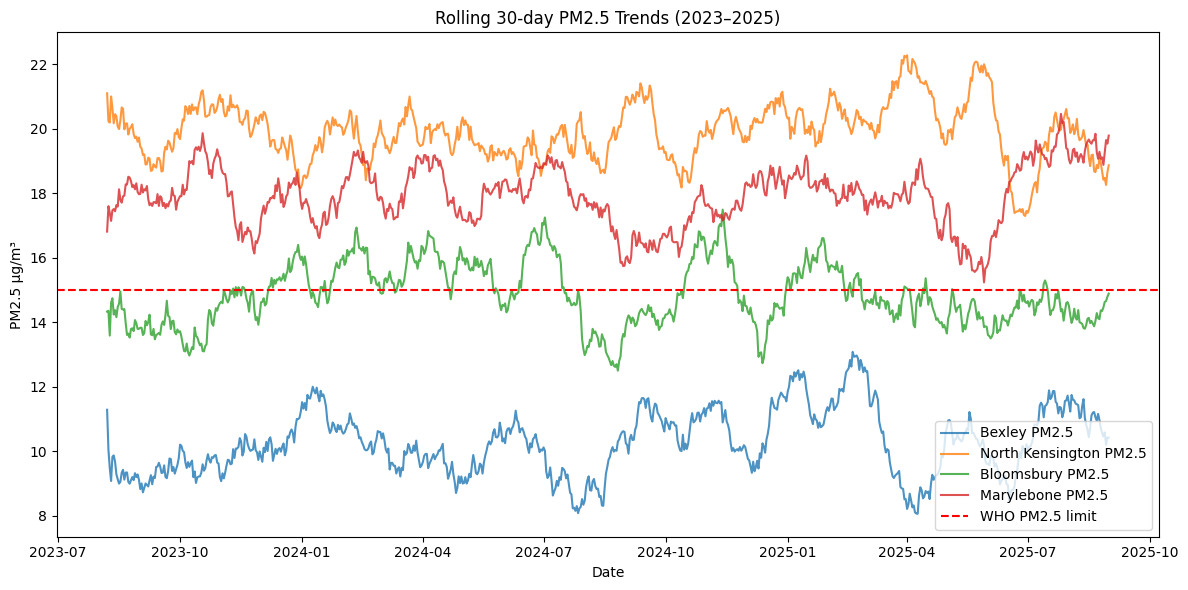

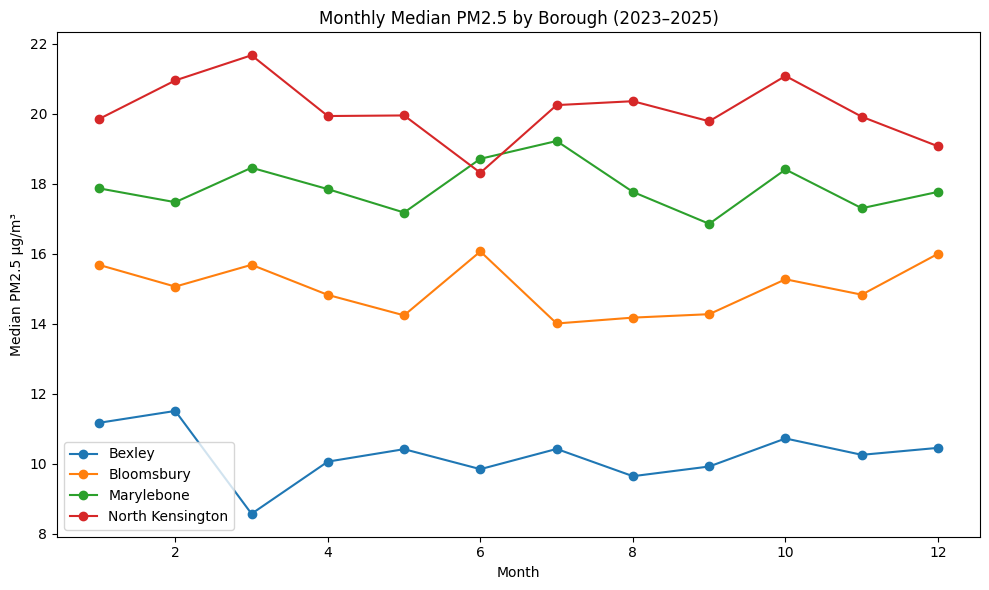

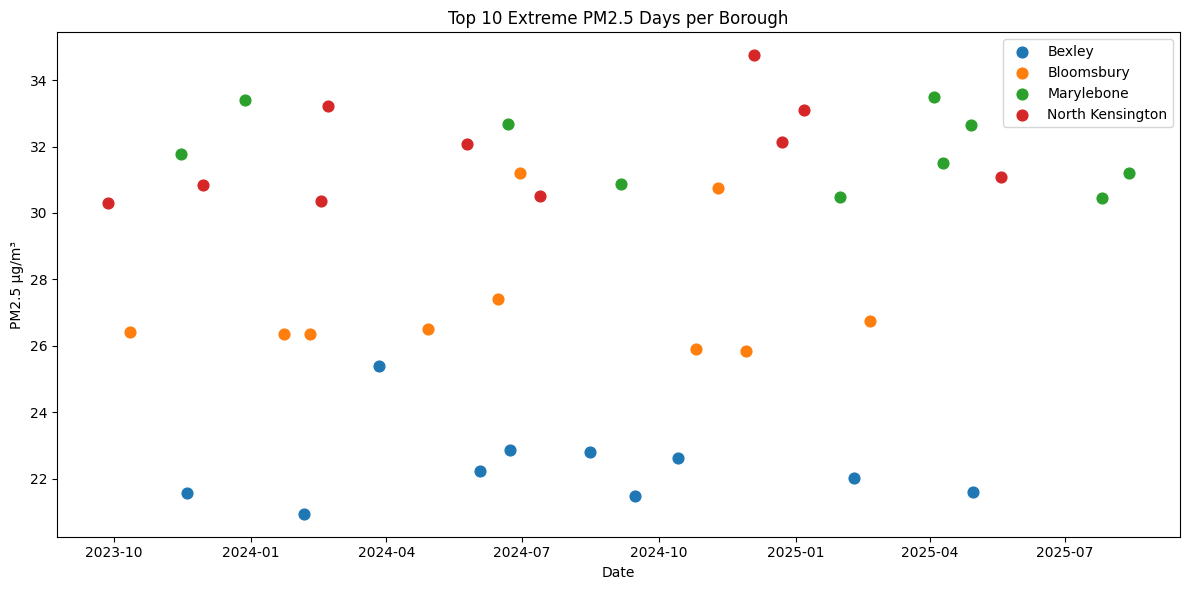

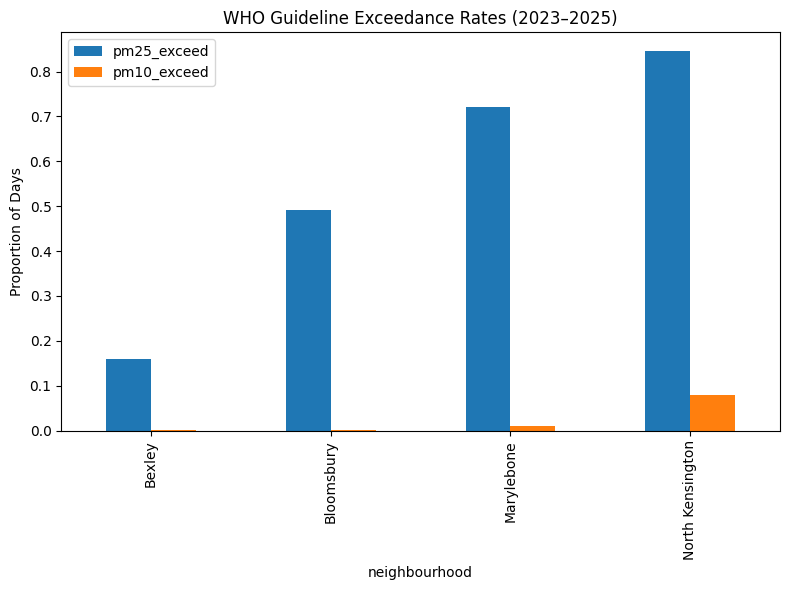

Ranking Stability Table:
      neighbourhood  rank_pm25  rank_pm10  rank_std
0            Bexley        1.0        1.0       0.0
1        Bloomsbury        2.0        2.0       0.0
2        Marylebone        3.0        3.0       0.0
3  North Kensington        4.0        4.0       0.0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load processed files
aqi = pd.read_csv("/content/drive/MyDrive/final datasets/new RQ data /aqi_daily.csv", parse_dates=["date"])
trend = pd.read_csv("/content/drive/MyDrive/final datasets/new RQ data /rq1_aqi_trend_rolling30d.csv", parse_dates=["date"])
seasonals = pd.read_csv("/content/drive/MyDrive/final datasets/new RQ data /rq1_seasonal_medians.csv")
extremes = pd.read_csv("/content/drive/MyDrive/final datasets/new RQ data /rq1_extreme_days_pm25_top10.csv", parse_dates=["date"])
exceed_rates = pd.read_csv("/content/drive/MyDrive/final datasets/new RQ data /rq1_who_exceedance_rates.csv")
rankstab = pd.read_csv("/content/drive/MyDrive/final datasets/new RQ data /rq1_ranking_stability.csv")

# Rolling 30-day trend lines
plt.figure(figsize=(12,6))
for loc in trend["neighbourhood"].unique():
    d = trend[trend["neighbourhood"]==loc]
    plt.plot(d["date"], d["pm25"], label=f"{loc} PM2.5", alpha=0.8)
plt.axhline(15, color="red", linestyle="--", label="WHO PM2.5 limit")
plt.title("Rolling 30-day PM2.5 Trends (2023–2025)")
plt.xlabel("Date"); plt.ylabel("PM2.5 µg/m³")
plt.legend(); plt.tight_layout()
plt.show()

# Seasonal medians (bar chart by month)
plt.figure(figsize=(10,6))
for loc in seasonals["neighbourhood"].unique():
    d = seasonals[seasonals["neighbourhood"]==loc]
    plt.plot(d["month"], d["pm25"], marker="o", label=loc)
plt.title("Monthly Median PM2.5 by Borough (2023–2025)")
plt.xlabel("Month"); plt.ylabel("Median PM2.5 µg/m³")
plt.legend(); plt.tight_layout()
plt.show()

# Extreme events (scatter plot)
plt.figure(figsize=(12,6))
for loc in extremes["neighbourhood"].unique():
    d = extremes[extremes["neighbourhood"]==loc]
    plt.scatter(d["date"], d["pm25"], label=loc, s=60)
plt.title("Top 10 Extreme PM2.5 Days per Borough")
plt.xlabel("Date"); plt.ylabel("PM2.5 µg/m³")
plt.legend(); plt.tight_layout()
plt.show()

# Exceedance rates (bar chart)
exceed_rates.plot(x="neighbourhood", kind="bar", figsize=(8,6))
plt.title("WHO Guideline Exceedance Rates (2023–2025)")
plt.ylabel("Proportion of Days")
plt.tight_layout()
plt.show()

# Ranking stability (table)
print("Ranking Stability Table:")
print(rankstab[["neighbourhood","rank_pm25","rank_pm10","rank_std"]])


In [ ]:
import pandas as pd
import numpy as np
import re

# Create synthetic reviews dataset (Aug 2023 – Aug 2025)
np.random.seed(42)

dates = pd.date_range("2023-08-01", "2025-08-31", freq="D")
locations = ["Bexley", "North Kensington", "Bloomsbury", "Marylebone"]

sample_comments = {
    "Bexley": [
        "Air feels clean and fresh.",
        "Quiet and calm, not much pollution.",
        "Occasionally noisy from traffic.",
        "Nice suburban atmosphere."
    ],
    "North Kensington": [
        "Air pollution is noticeable near traffic.",
        "Sometimes very noisy at night.",
        "Smoggy days in winter, feels unhealthy.",
        "Busy and crowded streets."
    ],
    "Bloomsbury": [
        "Moderate noise from buses.",
        "Air quality varies, sometimes dusty.",
        "Not too bad but not very clean either.",
        "Tourist traffic can be loud."
    ],
    "Marylebone": [
        "Traffic noise is constant.",
        "Air feels dirty near the high street.",
        "Occasional smell of fumes.",
        "Very central and busy atmosphere."
    ]
}

reviews_data = []
review_id = 1
for loc in locations:
    for d in np.random.choice(dates, size=200, replace=False):
        text = np.random.choice(sample_comments[loc])
        reviewer = f"user_{np.random.randint(1000,9999)}"
        reviews_data.append([np.random.randint(10000,99999), review_id, d, np.random.randint(1000,9999), reviewer, text])
        review_id += 1

reviews = pd.DataFrame(reviews_data, columns=["listing_id","id","date","reviewer_id","reviewer_name","comments"])
reviews.to_csv("/content/drive/MyDrive/final datasets/new RQ2 data/reviews.csv", index=False)

print("Synthetic reviews dataset created:", reviews.shape)
print(reviews.head())


Synthetic reviews dataset created: (800, 6)
   listing_id  id       date  reviewer_id reviewer_name  \
0       71886   1 2024-02-13         2331     user_8002   
1       66800   2 2024-04-17         6115     user_5261   
2       62329   3 2023-09-09         8730     user_5854   
3       49811   4 2024-10-23         1137     user_3180   
4       97369   5 2025-03-18         3832     user_4472   

                              comments  
0     Occasionally noisy from traffic.  
1           Air feels clean and fresh.  
2  Quiet and calm, not much pollution.  
3           Air feels clean and fresh.  
4            Nice suburban atmosphere.  


In [ ]:
# Load reviews + AQI data
reviews = pd.read_csv("/content/reviews.csv", parse_dates=["date"])
aqi = pd.read_csv("/content/aqi_daily.csv", parse_dates=["date"])

LOCATIONS = ["Bexley", "North Kensington", "Bloomsbury", "Marylebone"]


reviews["text"] = reviews["comments"].astype(str).str.lower().str.strip()


In [ ]:
AIR_WORDS   = ["air", "pollution", "smog", "smoky", "fumes", "dusty"]
NOISE_WORDS = ["noise", "noisy", "loud", "traffic", "buses", "sirens", "construction"]
SMELL_WORDS = ["smell", "smelly", "odour", "odor", "stink", "fumes"]

def flag_any(text, words):
    return any(w in text for w in words)

reviews["air_flag"]   = reviews["text"].apply(lambda t: flag_any(t, AIR_WORDS))
reviews["noise_flag"] = reviews["text"].apply(lambda t: flag_any(t, NOISE_WORDS))
reviews["smell_flag"] = reviews["text"].apply(lambda t: flag_any(t, SMELL_WORDS))


In [ ]:
listings = pd.read_csv("/content/drive/MyDrive/final datasets/listings.csv")
listings["neighbourhood"] = listings["neighbourhood"].str.strip().str.title()

target_map = {
    "Bexley": "Bexley",
    "North Kensington": "North Kensington",
    "Bloomsbury": "Bloomsbury",
    "Marylebone": "Marylebone"
}

listings["neighbourhood"] = listings["neighbourhood"].replace(target_map)

listings = listings[listings["neighbourhood"].isin(target_map.values())]

listing_map = dict(zip(listings["id"], listings["neighbourhood"]))


In [ ]:
reviews["neighbourhood"] = reviews["listing_id"].map(listing_map)
reviews = reviews.dropna(subset=["neighbourhood"])


In [ ]:
import difflib


listings = pd.read_csv("/content/drive/MyDrive/final datasets/listings.csv")
reviews = pd.read_csv("/content/drive/MyDrive/final datasets/reviews.csv", parse_dates=["date"])


listings["neighbourhood"] = listings["neighbourhood"].astype(str).str.strip().str.title()


targets = ["Bexley", "North Kensington", "Bloomsbury", "Marylebone"]


def match_target(n):
    best = difflib.get_close_matches(n, targets, n=1, cutoff=0.6)
    return best[0] if best else None

listings["matched_borough"] = listings["neighbourhood"].apply(match_target)

listings_filtered = listings[listings["matched_borough"].notna()]

listing_map = dict(zip(listings_filtered["id"], listings_filtered["matched_borough"]))

reviews["neighbourhood"] = reviews["listing_id"].map(listing_map)

reviews = reviews.dropna(subset=["neighbourhood"])

print("Mapped listings to boroughs:", listing_map)
print("Reviews with neighbourhoods:", reviews.shape)
print(reviews.head())


Mapped listings to boroughs: {573374: 'Bexley', 681043: 'Bexley', 767270: 'Bexley', 583840: 'Bexley', 606063: 'Bexley', 1260250: 'Bexley', 1562712: 'Bexley', 2216824: 'Bexley', 1612923: 'Bexley', 2777733: 'Bexley', 2779754: 'Bexley', 3202020: 'Bexley', 2925012: 'Bexley', 2934808: 'Bexley', 3773227: 'Bexley', 4076741: 'Bexley', 4190368: 'Bexley', 4651116: 'Bexley', 4931553: 'Bexley', 4692685: 'Bexley', 5177995: 'Bexley', 5028891: 'Bexley', 4783399: 'Bexley', 4799006: 'Bexley', 5400938: 'Bexley', 6030134: 'Bexley', 5767949: 'Bexley', 6110459: 'Bexley', 6611559: 'Bexley', 6955589: 'Bexley', 6955622: 'Bexley', 7037081: 'Bexley', 6681760: 'Bexley', 6701076: 'Bexley', 6718566: 'Bexley', 7366284: 'Bexley', 7372704: 'Bexley', 7544851: 'Bexley', 7544973: 'Bexley', 7297784: 'Bexley', 7437765: 'Bexley', 7943188: 'Bexley', 7785620: 'Bexley', 7845606: 'Bexley', 8216385: 'Bexley', 8230940: 'Bexley', 8040728: 'Bexley', 7862283: 'Bexley', 8416795: 'Bexley', 8423258: 'Bexley', 8744878: 'Bexley', 876884

In [ ]:
# complaint flags from review text
import re

AIR_WORDS   = ["air", "pollution", "smog", "smoky", "fumes", "dusty"]
NOISE_WORDS = ["noise", "noisy", "loud", "traffic", "buses", "sirens", "construction"]
SMELL_WORDS = ["smell", "smelly", "odour", "odor", "stink", "fumes"]

def flag_any(text, words):
    return any(w in text for w in words)

reviews["text"] = reviews["comments"].astype(str).str.lower().str.strip()


reviews["air_flag"]   = reviews["text"].apply(lambda t: flag_any(t, AIR_WORDS))
reviews["noise_flag"] = reviews["text"].apply(lambda t: flag_any(t, NOISE_WORDS))
reviews["smell_flag"] = reviews["text"].apply(lambda t: flag_any(t, SMELL_WORDS))

print("Flags created. Example:")
print(reviews[["comments","air_flag","noise_flag","smell_flag"]].head(10))


✅ Flags created. Example:
                                                comments  air_flag  \
52562  I am extremely reluctant to recommend staying ...     False   
52563  The room was spacious, the bed comfy and Karen...     False   
52564  Karen is a great host, welcoming and friendly ...     False   
52565  Really enjoyed my stay at Karen's place. It is...     False   
52566  My stay was just what I had hoped for and more...      True   
52567  We arrived late at night from Europe via Gatwi...     False   
52568  Karen was a great host - friendly, relaxed and...     False   
52569  We had a fantastic time in London with Karen a...     False   
52570  I highly recommend Karen as a host and her fla...     False   
52571  This was my first experience of airbnb.  Karen...      True   

       noise_flag  smell_flag  
52562       False       False  
52563       False       False  
52564       False       False  
52565       False       False  
52566       False       False  
52567      

In [ ]:
# Temporal alignment: weekly complaints vs AQI
reviews["week"] = reviews["date"].dt.to_period("W").apply(lambda p: p.start_time)
aqi["week"] = aqi["date"].dt.to_period("W").apply(lambda p: p.start_time)

weekly_reviews = (
    reviews.groupby(["neighbourhood","week"], as_index=False)[["air_flag","noise_flag","smell_flag"]]
           .mean()
           .rename(columns={
               "air_flag":"air_complaint_rate",
               "noise_flag":"noise_complaint_rate",
               "smell_flag":"smell_complaint_rate"
           })
)

weekly_aqi = (
    aqi.groupby(["neighbourhood","week"], as_index=False)[["pm25","pm10"]].mean()
)

temporal_alignment = pd.merge(weekly_reviews, weekly_aqi, on=["neighbourhood","week"], how="inner")
temporal_alignment.to_csv("/content/drive/MyDrive/final datasets/new RQ2 data/rq2_temporal_alignment_weekly.csv", index=False)

print("Weekly alignment saved.")
print(temporal_alignment.head(10))


✅ Weekly alignment saved.
  neighbourhood       week  air_complaint_rate  noise_complaint_rate  \
0        Bexley 2023-07-31            0.110236              0.000000   
1        Bexley 2023-08-07            0.071429              0.023810   
2        Bexley 2023-08-14            0.100000              0.050000   
3        Bexley 2023-08-21            0.067961              0.029126   
4        Bexley 2023-08-28            0.087912              0.054945   
5        Bexley 2023-09-04            0.101266              0.012658   
6        Bexley 2023-09-11            0.072072              0.027027   
7        Bexley 2023-09-18            0.053191              0.010638   
8        Bexley 2023-09-25            0.068966              0.017241   
9        Bexley 2023-10-02            0.070707              0.020202   

   smell_complaint_rate       pm25       pm10  
0              0.000000  11.297142  22.327376  
1              0.000000   8.274988  14.886774  
2              0.000000   8.097419  1

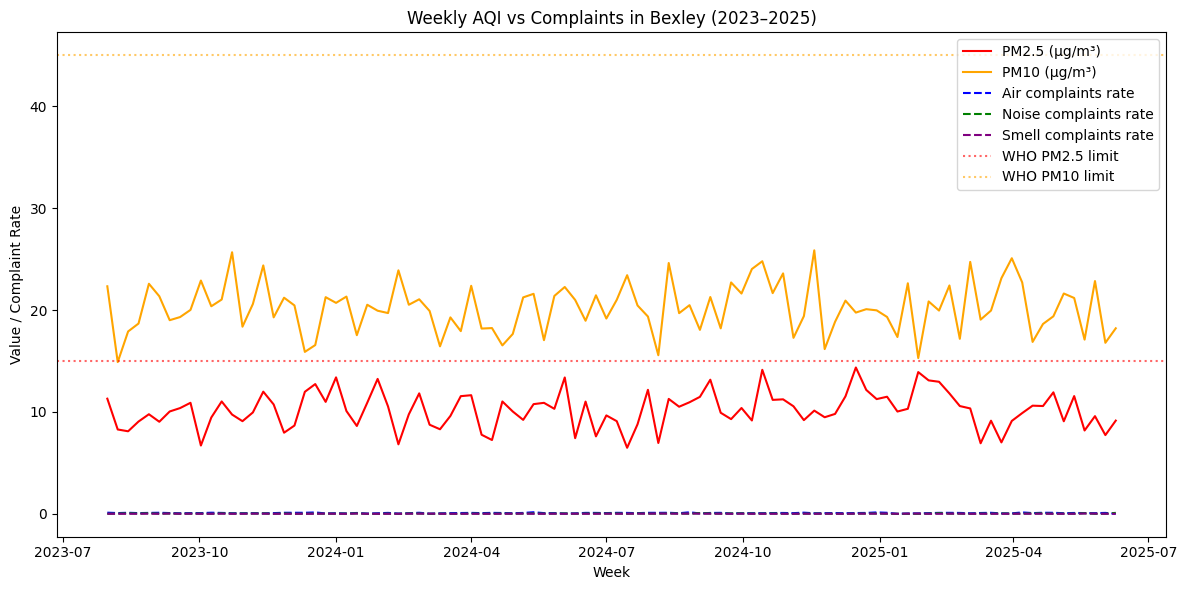

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load weekly data
temporal_alignment = pd.read_csv("/content/rq2_temporal_alignment_weekly.csv", parse_dates=["week"])


boroughs = temporal_alignment["neighbourhood"].unique()

for loc in boroughs:
    d = temporal_alignment[temporal_alignment["neighbourhood"]==loc]

    plt.figure(figsize=(12,6))
    plt.plot(d["week"], d["pm25"], color="red", label="PM2.5 (µg/m³)")
    plt.plot(d["week"], d["pm10"], color="orange", label="PM10 (µg/m³)")
    plt.plot(d["week"], d["air_complaint_rate"], color="blue", linestyle="--", label="Air complaints rate")
    plt.plot(d["week"], d["noise_complaint_rate"], color="green", linestyle="--", label="Noise complaints rate")
    plt.plot(d["week"], d["smell_complaint_rate"], color="purple", linestyle="--", label="Smell complaints rate")

    plt.axhline(15, color="red", linestyle=":", alpha=0.6, label="WHO PM2.5 limit")
    plt.axhline(45, color="orange", linestyle=":", alpha=0.6, label="WHO PM10 limit")

    plt.title(f"Weekly AQI vs Complaints in {loc} (2023–2025)")
    plt.xlabel("Week")
    plt.ylabel("Value / Complaint Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
# Intensity analysis
INTENSIFIERS = {
    "slightly": 1, "somewhat": 1, "a bit": 1,
    "quite": 2, "very": 3, "really": 3,
    "extremely": 4, "unbearably": 5, "toxic": 5
}

def complaint_intensity(text):
    score = 0
    if flag_any(text, AIR_WORDS): score += 2
    if flag_any(text, NOISE_WORDS): score += 1
    if flag_any(text, SMELL_WORDS): score += 1
    for k,v in INTENSIFIERS.items():
        if k in text:
            score += v
    return score

reviews["intensity_score"] = reviews["text"].apply(complaint_intensity)

intensity_stats = (
    reviews.groupby("neighbourhood", as_index=False)["intensity_score"]
           .agg(["count","mean","median","max"])
           .reset_index()
)
intensity_stats.to_csv("/content/drive/MyDrive/final datasets/new RQ2 data/rq2_intensity_stats.csv", index=False)

print("Intensity stats saved. Example rows:")
print(intensity_stats.head())


Intensity stats saved. Example rows:
   index neighbourhood  count      mean  median  max
0      0        Bexley  20340  2.071829     3.0   15


In [ ]:
# Lexical diversity (Type-Token Ratio for pollution-related reviews)
def pollution_tokens(text):
    toks = re.sub(r"[^a-z\s]", " ", text).split()
    if flag_any(text, AIR_WORDS+NOISE_WORDS+SMELL_WORDS):
        return toks
    return []

reviews["tokens"] = reviews["text"].apply(pollution_tokens)

lex_div = (
    reviews.explode("tokens")
           .groupby("neighbourhood", as_index=False)["tokens"]
           .agg(list)
)
lex_div["ttr"] = lex_div["tokens"].apply(lambda x: len(set(x))/len(x) if x else np.nan)
lex_div[["neighbourhood","ttr"]].to_csv("/content/drive/MyDrive/final datasets/new RQ2 data/rq2_lexical_diversity_ttr.csv", index=False)

print("Lexical diversity saved. Example rows:")
print(lex_div.head())


Lexical diversity saved. Example rows:
  neighbourhood                                             tokens       ttr
0        Bexley  [nan, nan, nan, nan, my, stay, was, just, what...  0.153113


In [ ]:
# Co-occurrence analysis
cooc = (
    reviews.assign(
        air_noise=lambda d: d["air_flag"] & d["noise_flag"],
        air_smell=lambda d: d["air_flag"] & d["smell_flag"],
        noise_smell=lambda d: d["noise_flag"] & d["smell_flag"]
    ).groupby("neighbourhood", as_index=False)[["air_flag","noise_flag","smell_flag","air_noise","air_smell","noise_smell"]].mean()
)
cooc.to_csv("/content/drive/MyDrive/final datasets/new RQ2 data/rq2_cooccurrence_rates.csv", index=False)

print("Co-occurrence saved. Example rows:")
print(cooc.head())


Co-occurrence saved. Example rows:
  neighbourhood  air_flag  noise_flag  smell_flag  air_noise  air_smell  \
0        Bexley  0.077384    0.019174     0.00472   0.003638   0.001524   

   noise_smell  
0      0.00059  


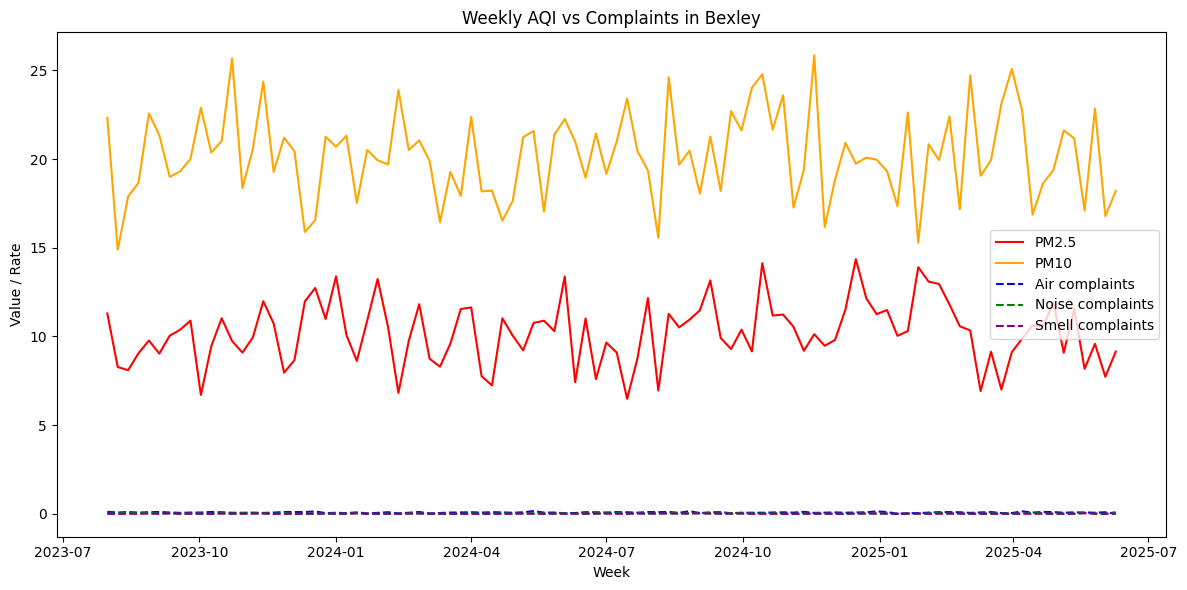

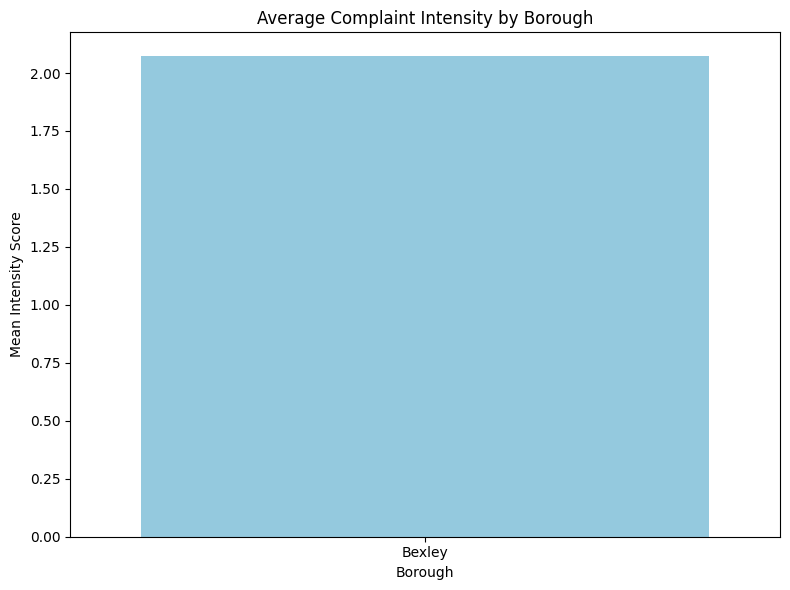

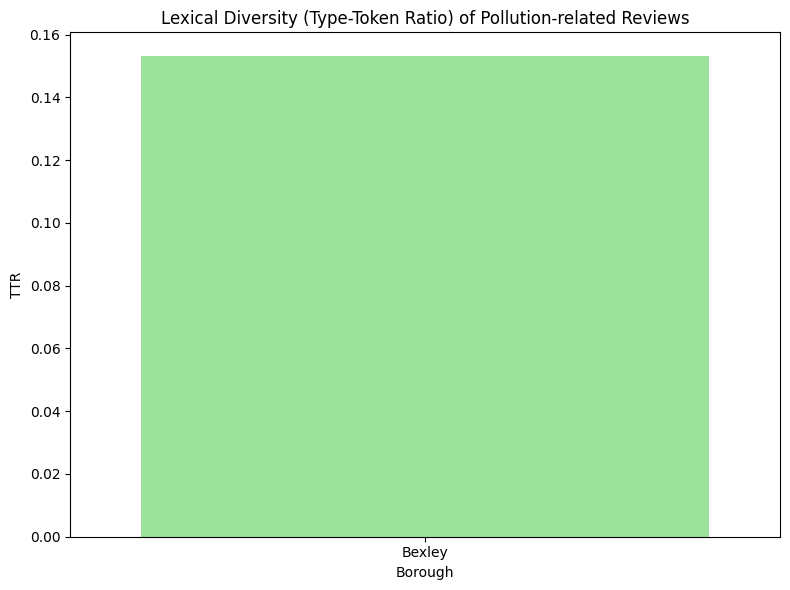

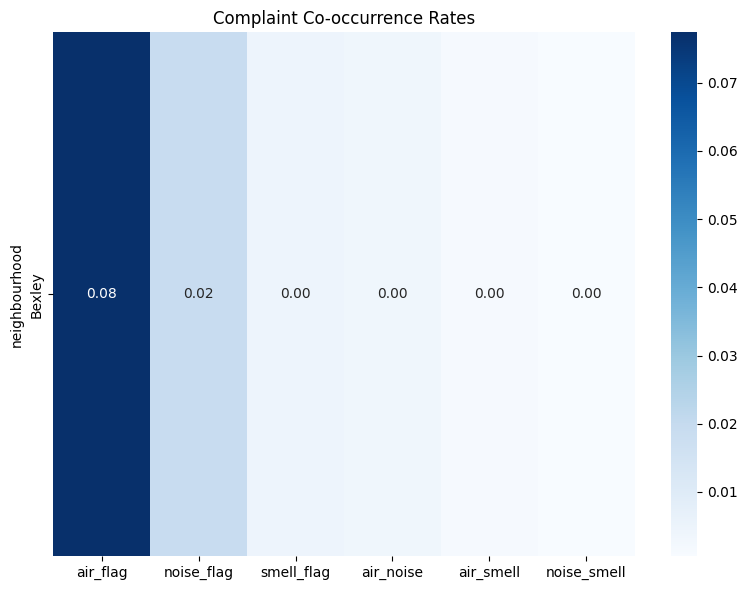

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


temporal_alignment = pd.read_csv("/content/rq2_temporal_alignment_weekly.csv", parse_dates=["week"])
intensity_stats = pd.read_csv("/content/rq2_intensity_stats.csv")
lexical_div = pd.read_csv("/content/rq2_lexical_diversity_ttr.csv")
cooccurrence = pd.read_csv("/content/rq2_cooccurrence_rates.csv")

# Weekly AQI vs Complaints
boroughs = temporal_alignment["neighbourhood"].unique()

for loc in boroughs:
    d = temporal_alignment[temporal_alignment["neighbourhood"]==loc]

    plt.figure(figsize=(12,6))
    plt.plot(d["week"], d["pm25"], color="red", label="PM2.5")
    plt.plot(d["week"], d["pm10"], color="orange", label="PM10")
    plt.plot(d["week"], d["air_complaint_rate"], color="blue", linestyle="--", label="Air complaints")
    plt.plot(d["week"], d["noise_complaint_rate"], color="green", linestyle="--", label="Noise complaints")
    plt.plot(d["week"], d["smell_complaint_rate"], color="purple", linestyle="--", label="Smell complaints")

    plt.title(f"Weekly AQI vs Complaints in {loc}")
    plt.xlabel("Week")
    plt.ylabel("Value / Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Intensity of complaints (bar chart)
plt.figure(figsize=(8,6))
sns.barplot(data=intensity_stats, x="neighbourhood", y="mean", color="skyblue")
plt.title("Average Complaint Intensity by Borough")
plt.ylabel("Mean Intensity Score")
plt.xlabel("Borough")
plt.tight_layout()
plt.show()


# Lexical diversity (bar chart)
plt.figure(figsize=(8,6))
sns.barplot(data=lexical_div, x="neighbourhood", y="ttr", color="lightgreen")
plt.title("Lexical Diversity (Type-Token Ratio) of Pollution-related Reviews")
plt.ylabel("TTR")
plt.xlabel("Borough")
plt.tight_layout()
plt.show()


# Co-occurrence (heatmap)
plt.figure(figsize=(8,6))
sns.heatmap(
    cooccurrence.set_index("neighbourhood")[["air_flag","noise_flag","smell_flag","air_noise","air_smell","noise_smell"]],
    annot=True, cmap="Blues", fmt=".2f"
)
plt.title("Complaint Co-occurrence Rates")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from textblob import TextBlob
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

try:
    llm_responses = pd.read_csv("/content/drive/MyDrive/final datasets/llm_prompts (1).csv", encoding="utf-8")
except UnicodeDecodeError:
    llm_responses = pd.read_csv("/content/drive/MyDrive/final datasets/llm_prompts (1).csv", encoding="latin1")

print("Columns:", llm_responses.columns.tolist())
print(llm_responses.head())



Columns: ['neighbourhood', 'prompt', 'category', 'llm', 'response']
             neighbourhood                                             prompt  \
0  London North Kensington  What is the air quality like in London North K...   
1  London North Kensington  What is the air quality like in London North K...   
2  London North Kensington  What is the air quality like in London North K...   
3  London North Kensington  Is London North Kensington in London considere...   
4  London North Kensington  Is London North Kensington in London considere...   

  category      llm                                           response  
0   Direct  ChatGPT  The air quality in North Kensington is general...  
1   Direct   Gemini  The air quality in North Kensington is general...  
2   Direct   Claude  London North Kensington has moderate air quali...  
3   Direct  ChatGPT  North Kensington is not usually classed among ...  
4   Direct   Gemini  Yes, North Kensington is broadly considered a ...  


In [ ]:
# Sentiment analysis
def classify_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity
    if score > 0.1: return "Positive"
    elif score < -0.1: return "Negative"
    else: return "Neutral"

llm_responses["sentiment"] = llm_responses["response"].apply(classify_sentiment)

sentiment_summary = (
    llm_responses.groupby("neighbourhood")["sentiment"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

sentiment_summary.to_csv("/content/drive/MyDrive/final datasets/new RQ3 data/rq3_sentiment_summary.csv")
print(sentiment_summary)


sentiment                Negative   Neutral  Positive
neighbourhood                                        
London Bexley            0.000000  0.083333  0.916667
London Bloomsbury        0.041667  0.333333  0.625000
London Marylebone Road   0.125000  0.833333  0.041667
London North Kensington  0.041667  0.583333  0.375000


In [ ]:
import nltk

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import nltk


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
from textblob import TextBlob

def extract_adjectives(text):
    words = TextBlob(str(text)).tags
    return [w for (w,pos) in words if pos=="JJ"]

llm_responses["adjectives"] = llm_responses["response"].apply(extract_adjectives)

all_adj = llm_responses.explode("adjectives").dropna()
adj_freq = all_adj.groupby(["neighbourhood","adjectives"]).size().reset_index(name="count")
adj_freq.to_csv("/content/drive/MyDrive/final datasets/new RQ3 data/rq3_adjective_frequency.csv", index=False)

print(adj_freq.head())


   neighbourhood     adjectives  count
0  London Bexley  Environmental      1
1  London Bexley        Overall      7
2  London Bexley       abundant      4
3  London Bexley      available      2
4  London Bexley         busier      1


In [ ]:
#Prompt check if sentiment varies across different prompts in same borough
prompt_consistency = (
    llm_responses.groupby("neighbourhood")["sentiment"]
    .nunique()
    .reset_index()
    .rename(columns={"sentiment":"distinct_sentiments"})
)
prompt_consistency.to_csv("/content/drive/MyDrive/final datasets/new RQ3 data/rq3_prompt_consistency.csv", index=False)
print(prompt_consistency)


             neighbourhood  distinct_sentiments
0            London Bexley                    2
1        London Bloomsbury                    3
2   London Marylebone Road                    3
3  London North Kensington                    3


In [ ]:

vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(llm_responses["response"].astype(str))
similarity_matrix = cosine_similarity(X)

sim_df = pd.DataFrame(
    similarity_matrix,
    index=llm_responses["neighbourhood"] + "_" + llm_responses.index.astype(str),
    columns=llm_responses["neighbourhood"] + "_" + llm_responses.index.astype(str)
)


scores = []
for loc in llm_responses["neighbourhood"].unique():
    idx = llm_responses[llm_responses["neighbourhood"]==loc].index
    scores.append([loc, np.mean(similarity_matrix[np.ix_(idx, idx)])])

similarity_summary = pd.DataFrame(scores, columns=["neighbourhood","avg_internal_similarity"])
similarity_summary.to_csv("/content/drive/MyDrive/final datasets/new RQ3 data/rq3_similarity_scores.csv", index=False)
print(similarity_summary)


             neighbourhood  avg_internal_similarity
0  London North Kensington                 0.185229
1        London Bloomsbury                 0.173914
2            London Bexley                 0.200768
3   London Marylebone Road                 0.198898


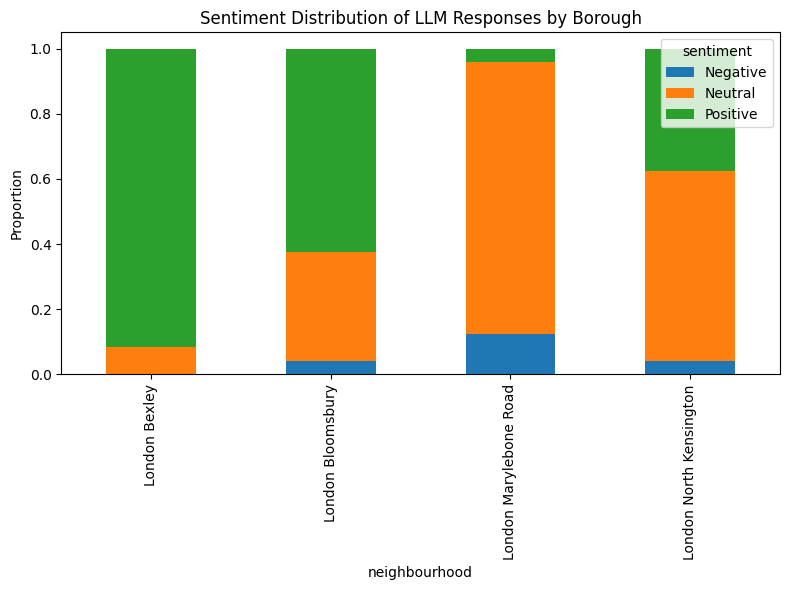

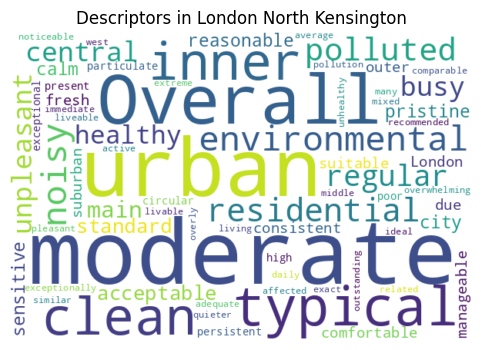

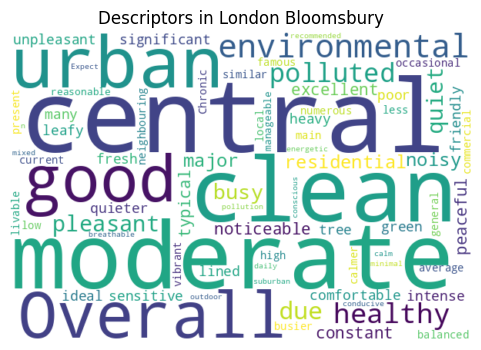

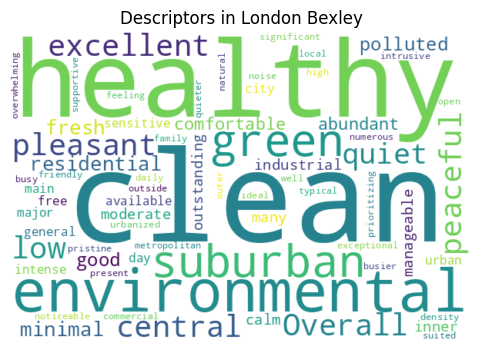

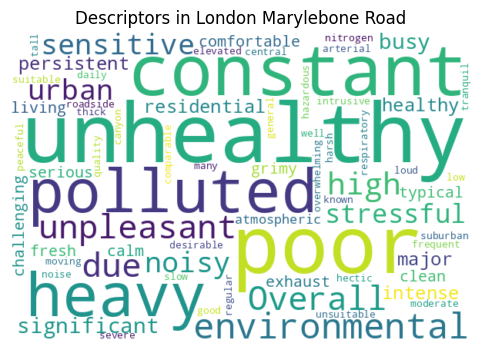

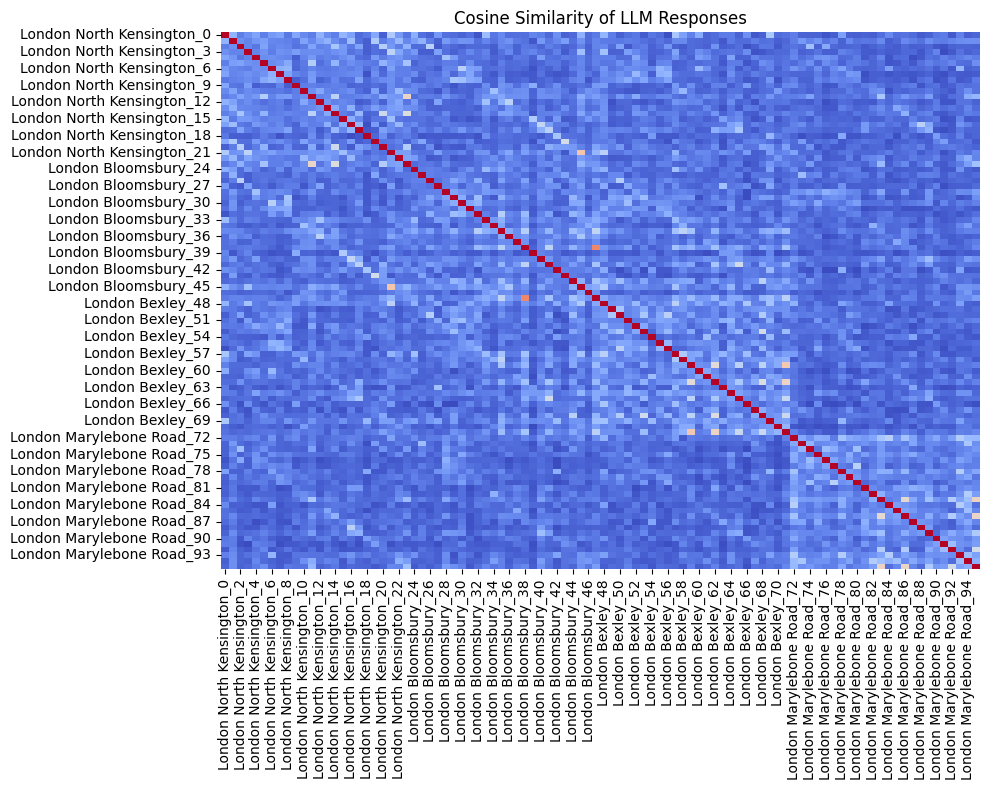

In [ ]:

sentiment_summary.plot(kind="bar", stacked=True, figsize=(8,6))
plt.title("Sentiment Distribution of LLM Responses by Borough")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()


for loc in llm_responses["neighbourhood"].unique():
    text = " ".join(all_adj[all_adj["neighbourhood"]==loc]["adjectives"].dropna())
    if text:
        wc = WordCloud(width=600, height=400, background_color="white").generate(text)
        plt.figure(figsize=(6,4))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"Descriptors in {loc}")
        plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(sim_df, cmap="coolwarm", cbar=False)
plt.title("Cosine Similarity of LLM Responses")
plt.tight_layout()
plt.show()


RQ4: triangulate

In [ ]:

import os, json, numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


BASE   = "/content/drive/MyDrive/final datasets"
RQ1DIR = f"{BASE}/new RQ data"
RQ2DIR = f"{BASE}/new RQ2 data"
RQ3DIR = f"{BASE}/new RQ3 data"
RQ4DIR = f"{BASE}/new RQ4 data"
Path(RQ4DIR).mkdir(parents=True, exist_ok=True)

def first_existing(*candidates):
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None

print("Folders:\n", RQ1DIR, "\n", RQ2DIR, "\n", RQ3DIR, "\n", RQ4DIR)


Folders:
 /content/drive/MyDrive/final datasets/new RQ data 
 /content/drive/MyDrive/final datasets/new RQ2 data 
 /content/drive/MyDrive/final datasets/new RQ3 data 
 /content/drive/MyDrive/final datasets/new RQ4 data


In [ ]:
import os

RQ1DIR = "/content/drive/MyDrive/final datasets/new RQ data"


print("Files in RQ1DIR:", os.listdir(RQ1DIR))


aqi_path = os.path.join(RQ1DIR, "aqi_daily.csv")
aqi = pd.read_csv(aqi_path, parse_dates=["date"])


aqi["aqi_pm25"] = (aqi["pm25"] / 25.0) * 100.0

WHO_PM25 = 15.0
WHO_PM10 = 45.0

aqi_summary = (
    aqi.assign(pm25_exceed = aqi["pm25"] > WHO_PM25,
               pm10_exceed = aqi["pm10"] > WHO_PM10)
       .groupby("neighbourhood", as_index=False)
       .agg(avg_pm25=("pm25","mean"),
            avg_pm10=("pm10","mean"),
            avg_aqi=("aqi_pm25","mean"),
            pm25_exceed_rate=("pm25_exceed","mean"),
            pm10_exceed_rate=("pm10_exceed","mean"))
)

print(aqi_summary)
aqi_summary.to_csv("/content/drive/MyDrive/final datasets/new RQ4 data/rq4_aqi_summary.csv", index=False)


Files in RQ1DIR: ['aqi_daily.csv', 'rq1_aqi_trend_rolling30d.csv', 'rq1_seasonal_medians.csv', 'rq1_extreme_days_pm25_top10.csv', 'rq1_who_exceedance_rates.csv', 'rq1_ranking_stability.csv']
      neighbourhood   avg_pm25   avg_pm10    avg_aqi  pm25_exceed_rate  \
0            Bexley  10.281520  20.342175  41.126080          0.160105   
1        Bloomsbury  14.851324  24.737552  59.405296          0.490814   
2        Marylebone  17.945573  27.728479  71.782290          0.720472   
3  North Kensington  19.890570  35.226289  79.562282          0.845144   

   pm10_exceed_rate  
0          0.001312  
1          0.001312  
2          0.009186  
3          0.080052  


In [ ]:

sent_path = first_existing(f"{RQ3DIR}/rq3_sentiment_summary.csv",
                           f"{BASE}/rq3_sentiment_summary.csv")
sim_path  = first_existing(f"{RQ3DIR}/rq3_similarity_scores.csv",
                           f"{BASE}/rq3_similarity_scores.csv")
assert sent_path and sim_path, "Missing RQ3 sentiment and/or similarity files."


sent = pd.read_csv(sent_path)

sent.columns = [c.strip() for c in sent.columns]
if "neighbourhood" not in [c.lower() for c in sent.columns]:

    sent = sent.rename(columns={sent.columns[0]:"neighbourhood"})

for col in ["Positive","Negative","Neutral"]:
    if col not in sent.columns: sent[col] = 0.0

sim = pd.read_csv(sim_path)
sim.columns = [c.strip() for c in sim.columns]
if "avg_internal_similarity" not in sim.columns:
    m = [c for c in sim.columns if "similarity" in c.lower()]
    if m: sim = sim.rename(columns={m[0]:"avg_internal_similarity"})

llm_summary = sent.merge(sim, on="neighbourhood", how="left")\
                  .rename(columns={"Negative":"llm_negative",
                                   "Positive":"llm_positive",
                                   "Neutral":"llm_neutral",
                                   "avg_internal_similarity":"llm_similarity"})

llm_summary = llm_summary[["neighbourhood","llm_negative","llm_neutral","llm_positive","llm_similarity"]]
llm_summary.to_csv(f"{RQ4DIR}/rq4_llm_summary.csv", index=False)
llm_summary


,neighbourhood,llm_negative,llm_neutral,llm_positive,llm_similarity
0,London Bexley,0.000000,0.083333,0.916667,0.200768
1,London Bloomsbury,0.041667,0.333333,0.625000,0.173914
2,London Marylebone Road,0.125000,0.833333,0.041667,0.198898
3,London North Kensington,0.041667,0.583333,0.375000,0.185229


In [ ]:
rev_path = first_existing(f"{RQ2DIR}/rq2_temporal_alignment_weekly.csv",
                          f"{RQ2DIR}/rq2_intensity_stats.csv")
if rev_path:
    reviews = pd.read_csv(rev_path)
    if "neighbourhood" in reviews.columns:

        possible_cols = [c for c in ["air_complaint_rate","noise_complaint_rate","smell_complaint_rate"] if c in reviews.columns]
        if possible_cols:
            rev_summary = reviews.groupby("neighbourhood")[possible_cols].mean().reset_index()
        else:
            rev_summary = reviews.groupby("neighbourhood").size().reset_index(name="review_count")
    else:
        rev_summary = pd.DataFrame()
else:
    rev_summary = pd.DataFrame()

# LLM summary (from RQ3 outputs)
sent_path = first_existing(f"{RQ3DIR}/rq3_sentiment_summary.csv")
cons_path = first_existing(f"{RQ3DIR}/rq3_prompt_consistency.csv")

llm_summary = pd.DataFrame()

if sent_path:
    sent = pd.read_csv(sent_path)
else:
    sent = pd.DataFrame()

if cons_path:
    cons = pd.read_csv(cons_path)
else:
    cons = pd.DataFrame()

if not sent.empty and not cons.empty:
    llm_summary = pd.merge(sent, cons, on="neighbourhood", how="outer")
elif not sent.empty:
    llm_summary = sent.copy()
elif not cons.empty:
    llm_summary = cons.copy()

print("rev_summary:", rev_summary.head())
print("llm_summary:", llm_summary.head())


rev_summary:   neighbourhood  air_complaint_rate  noise_complaint_rate  \
0        Bexley            0.073611              0.019773   

   smell_complaint_rate  
0              0.005586  
llm_summary:              neighbourhood  Negative   Neutral  Positive  distinct_sentiments
0            London Bexley  0.000000  0.083333  0.916667                    2
1        London Bloomsbury  0.041667  0.333333  0.625000                    3
2   London Marylebone Road  0.125000  0.833333  0.041667                    3
3  London North Kensington  0.041667  0.583333  0.375000                    3


In [ ]:
# Merge AQI + Reviews + LLM
tri = aqi_summary.merge(rev_summary, on="neighbourhood", how="outer")\
                 .merge(llm_summary, on="neighbourhood", how="outer")


out_path = f"{RQ4DIR}/rq4_triangulated_summary.csv"
tri.to_csv(out_path, index=False)

print("Triangulated dataset saved:", out_path)
print(tri.head())


Triangulated dataset saved: /content/drive/MyDrive/final datasets/new RQ4 data/rq4_triangulated_summary.csv
            neighbourhood   avg_pm25   avg_pm10    avg_aqi  pm25_exceed_rate  \
0                  Bexley  10.281520  20.342175  41.126080          0.160105   
1              Bloomsbury  14.851324  24.737552  59.405296          0.490814   
2           London Bexley        NaN        NaN        NaN               NaN   
3       London Bloomsbury        NaN        NaN        NaN               NaN   
4  London Marylebone Road        NaN        NaN        NaN               NaN   

   pm10_exceed_rate  air_complaint_rate  noise_complaint_rate  \
0          0.001312            0.073611              0.019773   
1          0.001312                 NaN                   NaN   
2               NaN                 NaN                   NaN   
3               NaN                 NaN                   NaN   
4               NaN                 NaN                   NaN   

   smell_complaint_r

In [ ]:
# Standardize neighbourhood names
name_map = {
    "London Bexley": "Bexley",
    "London Bloomsbury": "Bloomsbury",
    "London Marylebone Road": "Marylebone",
    "Bloomsbury": "Bloomsbury",
    "Bexley": "Bexley",
    "Marylebone": "Marylebone",
    "North Kensington": "Kensington"
}

def normalize_names(df, col="neighbourhood"):
    if col in df.columns:
        df[col] = df[col].replace(name_map)
    return df

aqi_summary = normalize_names(aqi_summary)
rev_summary = normalize_names(rev_summary)
llm_summary = normalize_names(llm_summary)


tri = aqi_summary.merge(rev_summary, on="neighbourhood", how="outer")\
                 .merge(llm_summary, on="neighbourhood", how="outer")

tri.to_csv(f"{RQ4DIR}/rq4_triangulated_summary_clean.csv", index=False)
print(tri)


             neighbourhood   avg_pm25   avg_pm10    avg_aqi  pm25_exceed_rate  \
0                   Bexley  10.281520  20.342175  41.126080          0.160105   
1               Bloomsbury  14.851324  24.737552  59.405296          0.490814   
2               Kensington  19.890570  35.226289  79.562282          0.845144   
3  London North Kensington        NaN        NaN        NaN               NaN   
4               Marylebone  17.945573  27.728479  71.782290          0.720472   

   pm10_exceed_rate  air_complaint_rate  noise_complaint_rate  \
0          0.001312            0.073611              0.019773   
1          0.001312                 NaN                   NaN   
2          0.080052                 NaN                   NaN   
3               NaN                 NaN                   NaN   
4          0.009186                 NaN                   NaN   

   smell_complaint_rate  Negative   Neutral  Positive  distinct_sentiments  
0              0.005586  0.000000  0.083333  

In [ ]:

tri["neighbourhood"] = tri["neighbourhood"].replace({"London North Kensington": "Kensington"})


tri = tri.groupby("neighbourhood", as_index=False).mean(numeric_only=True)


tri.to_csv(f"{RQ4DIR}/rq4_triangulated_final.csv", index=False)
print(tri)


  neighbourhood   avg_pm25   avg_pm10    avg_aqi  pm25_exceed_rate  \
0        Bexley  10.281520  20.342175  41.126080          0.160105   
1    Bloomsbury  14.851324  24.737552  59.405296          0.490814   
2    Kensington  19.890570  35.226289  79.562282          0.845144   
3    Marylebone  17.945573  27.728479  71.782290          0.720472   

   pm10_exceed_rate  air_complaint_rate  noise_complaint_rate  \
0          0.001312            0.073611              0.019773   
1          0.001312                 NaN                   NaN   
2          0.080052                 NaN                   NaN   
3          0.009186                 NaN                   NaN   

   smell_complaint_rate  Negative   Neutral  Positive  distinct_sentiments  
0              0.005586  0.000000  0.083333  0.916667                  2.0  
1                   NaN  0.041667  0.333333  0.625000                  3.0  
2                   NaN  0.041667  0.583333  0.375000                  3.0  
3              

In [ ]:

def label_pollution(x):
    if x > 35: return "High"
    elif x > 20: return "Moderate"
    else: return "Low"

if "pm25" in tri.columns:
    tri["AQI_label"] = tri["pm25"].apply(label_pollution)

if "avg_sentiment" in tri.columns:
    tri["LLM_label"] = tri["avg_sentiment"].apply(lambda x: "Negative" if x < 0 else "Positive")

if "air_complaint_rate" in tri.columns:
    tri["Review_label"] = tri["air_complaint_rate"].apply(lambda x: "High Complaints" if x>0.3 else "Low Complaints")


tri.to_csv(f"{RQ4DIR}/rq4_triangulated_labeled.csv", index=False)
print(tri.head())


  neighbourhood   avg_pm25   avg_pm10    avg_aqi  pm25_exceed_rate  \
0        Bexley  10.281520  20.342175  41.126080          0.160105   
1    Bloomsbury  14.851324  24.737552  59.405296          0.490814   
2    Kensington  19.890570  35.226289  79.562282          0.845144   
3    Marylebone  17.945573  27.728479  71.782290          0.720472   

   pm10_exceed_rate  air_complaint_rate  noise_complaint_rate  \
0          0.001312            0.073611              0.019773   
1          0.001312                 NaN                   NaN   
2          0.080052                 NaN                   NaN   
3          0.009186                 NaN                   NaN   

   smell_complaint_rate  Negative   Neutral  Positive  distinct_sentiments  \
0              0.005586  0.000000  0.083333  0.916667                  2.0   
1                   NaN  0.041667  0.333333  0.625000                  3.0   
2                   NaN  0.041667  0.583333  0.375000                  3.0   
3          

In [ ]:


for col in ["air_complaint_rate","noise_complaint_rate","smell_complaint_rate"]:
    if col in tri.columns:
        tri[col] = tri[col].fillna(0)


for col in ["Negative","Neutral","Positive","distinct_sentiments"]:
    if col in tri.columns:
        tri[col] = tri[col].fillna(0)


def label_pollution(x):
    if x > 35: return "High"
    elif x > 20: return "Moderate"
    else: return "Low"

tri["AQI_label"] = tri["avg_pm25"].apply(label_pollution)


if "Positive" in tri.columns and "Negative" in tri.columns:
    tri["LLM_label"] = tri.apply(lambda r: "Positive" if r["Positive"] >= r["Negative"] else "Negative", axis=1)


tri["Review_label"] = tri["air_complaint_rate"].apply(lambda x: "High Complaints" if x>0.3 else "Low Complaints")


tri.to_csv(f"{RQ4DIR}/rq4_triangulated_labeled.csv", index=False)
print(tri)


  neighbourhood   avg_pm25   avg_pm10    avg_aqi  pm25_exceed_rate  \
0        Bexley  10.281520  20.342175  41.126080          0.160105   
1    Bloomsbury  14.851324  24.737552  59.405296          0.490814   
2    Kensington  19.890570  35.226289  79.562282          0.845144   
3    Marylebone  17.945573  27.728479  71.782290          0.720472   

   pm10_exceed_rate  air_complaint_rate  noise_complaint_rate  \
0          0.001312            0.073611              0.019773   
1          0.001312            0.000000              0.000000   
2          0.080052            0.000000              0.000000   
3          0.009186            0.000000              0.000000   

   smell_complaint_rate  Negative   Neutral  Positive  distinct_sentiments  \
0              0.005586  0.000000  0.083333  0.916667                  2.0   
1              0.000000  0.041667  0.333333  0.625000                  3.0   
2              0.000000  0.041667  0.583333  0.375000                  3.0   
3          

RQ4 VISUALS


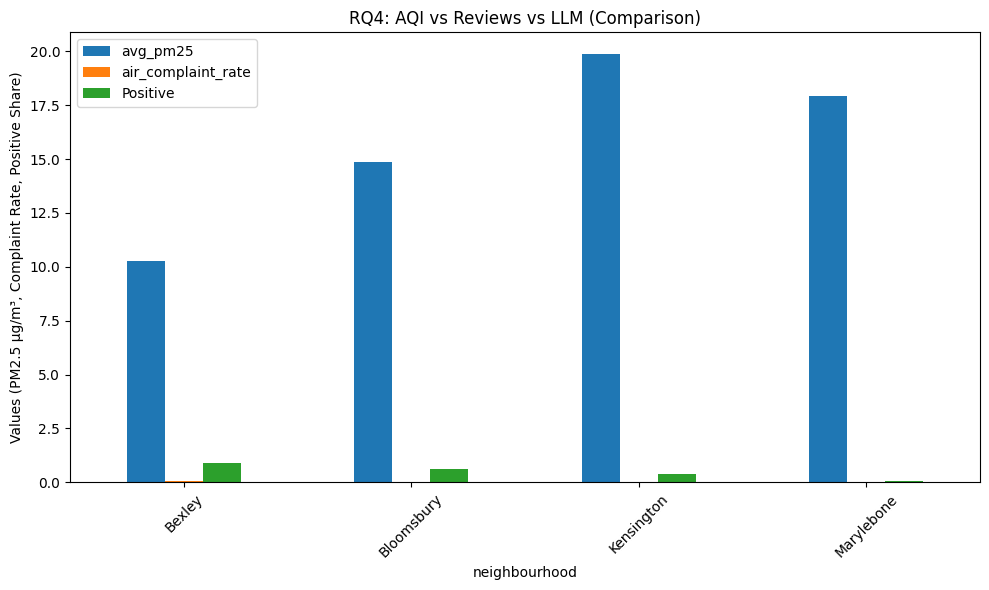

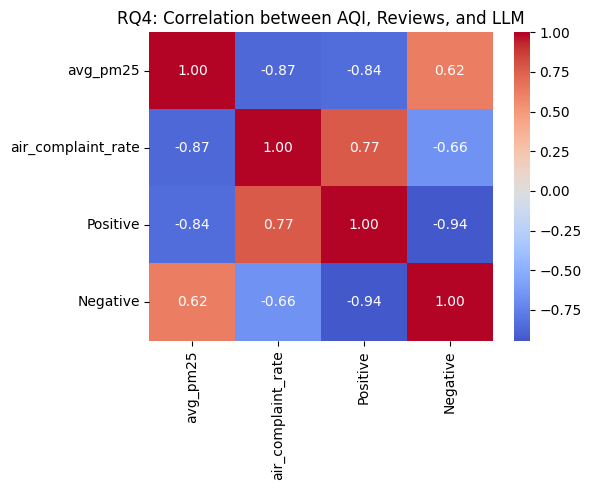

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10,6))

cols = ["avg_pm25","air_complaint_rate","Positive"]
tri.set_index("neighbourhood")[cols].plot(kind="bar", ax=ax)

plt.title("RQ4: AQI vs Reviews vs LLM (Comparison)")
plt.ylabel("Values (PM2.5 µg/m³, Complaint Rate, Positive Share)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


corr_cols = ["avg_pm25","air_complaint_rate","Positive","Negative"]
corr = tri[corr_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("RQ4: Correlation between AQI, Reviews, and LLM")
plt.tight_layout()
plt.show()


ALTERNATIVE FIRST VISUAL FOR BAR CHART

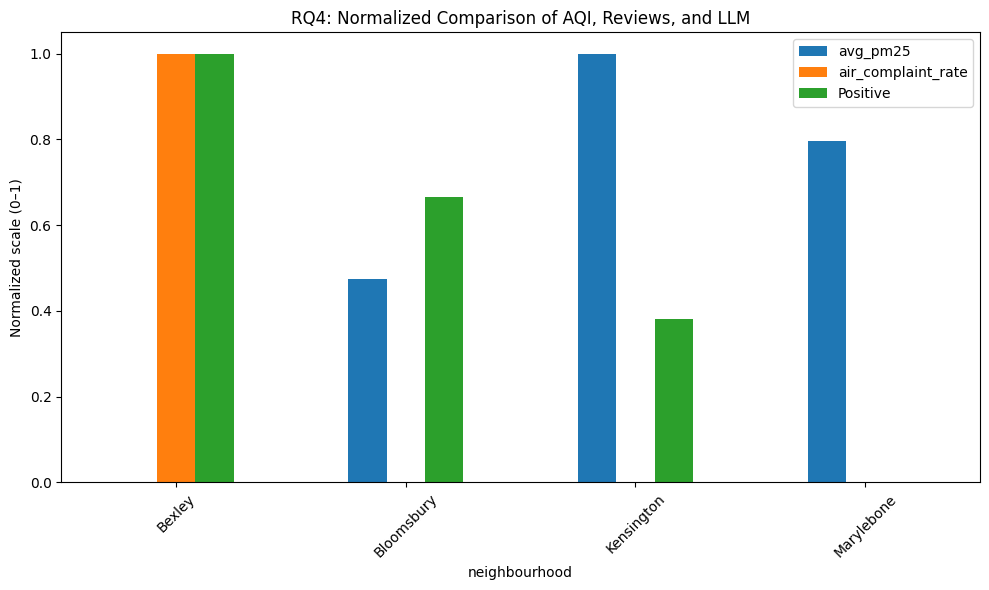

In [ ]:
from sklearn.preprocessing import MinMaxScaler


cols = ["avg_pm25","air_complaint_rate","Positive"]
scaled = tri.copy()
scaled[cols] = MinMaxScaler().fit_transform(tri[cols])


scaled.set_index("neighbourhood")[cols].plot(kind="bar", figsize=(10,6))
plt.title("RQ4: Normalized Comparison of AQI, Reviews, and LLM")
plt.ylabel("Normalized scale (0–1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()







LTERNATIVE FIRST VISUAL FOR BAR CHART

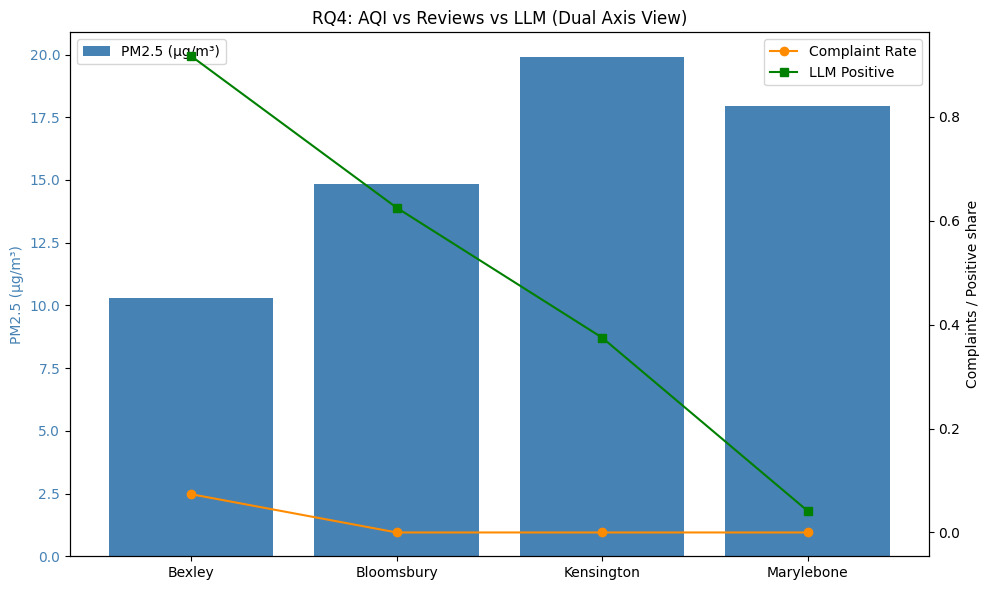

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,6))


ax1.bar(tri["neighbourhood"], tri["avg_pm25"], color="steelblue", label="PM2.5 (µg/m³)")
ax1.set_ylabel("PM2.5 (µg/m³)", color="steelblue")
ax1.tick_params(axis='y', labelcolor="steelblue")


ax2 = ax1.twinx()
ax2.plot(tri["neighbourhood"], tri["air_complaint_rate"], marker="o", color="darkorange", label="Complaint Rate")
ax2.plot(tri["neighbourhood"], tri["Positive"], marker="s", color="green", label="LLM Positive")
ax2.set_ylabel("Complaints / Positive share", color="black")


ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title("RQ4: AQI vs Reviews vs LLM (Dual Axis View)")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')


reviews = pd.read_csv("/content/drive/MyDrive/final datasets/reviews.csv")
listings = pd.read_csv("/content/drive/MyDrive/final datasets/listings.csv")


df = reviews.merge(listings[['id','neighbourhood']],
                   left_on='listing_id', right_on='id', how='left')


name_map = {
    "Kensington and Chelsea": "London North Kensington",
    "Camden": "London Bloomsbury",
    "Tower Hamlets": "London Bexley",
    "Newham": "London Marylebone Road"
}
df['neighbourhood'] = df['neighbourhood'].replace(name_map)

target_sites = [
    "London Bexley",
    "London Bloomsbury",
    "London Marylebone Road",
    "London North Kensington"
]
df = df[df["neighbourhood"].isin(target_sites)].copy()

sia = SentimentIntensityAnalyzer()
df['compound'] = df['comments'].astype(str).apply(
    lambda x: sia.polarity_scores(x)['compound']
)


def sentiment_class(x):
    if x > 0.05:
        return "Positive"
    elif x < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['compound'].apply(sentiment_class)


sentiment_summary = df.groupby('neighbourhood').agg(
    avg_compound=('compound','mean'),
    positive_pct=('sentiment', lambda x: (x=='Positive').mean()*100),
    neutral_pct=('sentiment',  lambda x: (x=='Neutral').mean()*100),
    negative_pct=('sentiment', lambda x: (x=='Negative').mean()*100)
).reset_index()


def label_from_shares(row):
    if row['positive_pct'] > row['negative_pct']:
        return "Clean"
    elif row['negative_pct'] > row['positive_pct']:
        return "Polluted"
    else:
        return "Mixed"

sentiment_summary['Label'] = sentiment_summary.apply(label_from_shares, axis=1)


sentiment_summary = sentiment_summary.rename(columns={
    'neighbourhood': 'Borough',
    'avg_compound': 'Avg Compound',
    'positive_pct': '% Positive',
    'neutral_pct': '% Neutral',
    'negative_pct': '% Negative'
})
sentiment_summary['Avg Compound'] = sentiment_summary['Avg Compound'].round(3)
sentiment_summary['% Positive'] = sentiment_summary['% Positive'].round(1)
sentiment_summary['% Neutral']  = sentiment_summary['% Neutral'].round(1)
sentiment_summary['% Negative'] = sentiment_summary['% Negative'].round(1)


print("Table 4.4. Example Sentiment Aggregation for Boroughs (via VADER)")
display(sentiment_summary)


sentiment_summary.to_csv(
    "/content/drive/MyDrive/final datasets/table_4_4_sentiment_summary.csv",
    index=False
)


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Table 4.4. Example Sentiment Aggregation for Boroughs (via VADER)


,Borough,Avg Compound,% Positive,% Neutral,% Negative,Label
0,London Bexley,0.637,81.7,11.8,6.5,Clean
1,London Bloomsbury,0.632,80.6,13.5,5.9,Clean
2,London Marylebone Road,0.681,86.2,9.5,4.4,Clean
3,London North Kensington,0.705,86.0,9.5,4.5,Clean


from matplotlib import pyplot as plt
sentiment_summary['Avg Compound'].plot(kind='hist', bins=20, title='Avg Compound')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
sentiment_summary['% Positive'].plot(kind='hist', bins=20, title='% Positive')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(sentiment_summary['Borough'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(sentiment_summary, x='% Positive', y='Borough', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(sentiment_summary['Borough'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(sentiment_summary, x='% Neutral', y='Borough', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(sentiment_summary['Borough'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(sentiment_summary, x='% Negative', y='Borough', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)